# This notebook was used to test Grad-CAM on a variety of sequences for both Transformer-40k and SpliceAI-10k

I went through a few iterations of how I implemented Grad-CAM, eventually scaling up to handle the full ten models for each Transformer-40k and SpliceAI_10k and with multiple layers (res_layers and skip_layers). I left all my previous iterations in case they are useful, but skip to the section about multiple layers for the most recent version.

In [1]:
import numpy as np
import sys
import time
import h5py
from tqdm import tqdm

import numpy as np
import re
from math import ceil
from sklearn.metrics import average_precision_score
from torch.utils.data import Dataset
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import pickle
#import pickle5 as pickle
import os
from sklearn.model_selection import train_test_split

from scipy.sparse import load_npz
from glob import glob

from transformers import get_constant_schedule_with_warmup
from sklearn.metrics import precision_score,recall_score,accuracy_score

from src.train import trainModel
from src.dataloader import getData,spliceDataset,h5pyDataset,collate_fn, getDataPointListFull
from src.weight_init import keras_init
from src.losses import categorical_crossentropy_2d
from src.model_gradcam import SpliceFormer, SpliceAI_10K
from src.evaluation_metrics import print_topl_statistics
import copy
from collections import defaultdict

/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
data_dir = '../Data'
SL=5000
CL_max=40000
setType = 'test'
annotation_test, transcriptToLabel_test, seqData = getData(data_dir, setType) 
BATCH_SIZE = 1
specific_anno = annotation_test[annotation_test['name'].apply(lambda x: x.split('--')[0])=='CFTR']

### This section is just what I used to test Grad-CAM on a single layer for a single model before extending to multiple layers/models. Can be skipped

In [4]:
device = torch.device("cpu")
model_m = SpliceFormer(CL_max,determenistic=True, crop=False)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)
model_m = nn.DataParallel(model_m)
output_class_labels = ['Null', 'Acceptor', 'Donor']

n_models = 10

model_m.load_state_dict(torch.load('../Results/PyTorch_Models/transformer_encoder_45k_171022_0',map_location=device))
model_m.eval()


DataParallel(
  (module): SpliceFormer(
    (SpliceAI): SpliceAI(
      (conv_layer_1): Conv1d(4, 32, kernel_size=(1,), stride=(1,))
      (skip_layers): ModuleList(
        (0-4): 5 x Conv1d(32, 32, kernel_size=(1,), stride=(1,))
      )
      (res_layers): ModuleList(
        (0): ResComboBlock(
          (comboBlock): Sequential(
            (0): ResidualBlock(
              (convlayer1): Conv1d(32, 32, kernel_size=(11,), stride=(1,), padding=(5,))
              (convlayer2): Conv1d(32, 32, kernel_size=(11,), stride=(1,), padding=(5,))
              (activate): ReLU(inplace=True)
              (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
              (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
              (shortcut): Identity()
            )
            (1): ResidualBlock(
              (convlayer1): Conv1d(32, 32, kernel_size=(11,), stride=(1,), padding=(5,))
              (convlayer2): Conv1d

In [3]:
BATCH_SIZE = 1
specific_anno = annotation_test[annotation_test['name'].apply(lambda x: x.split('--')[0])=='CFTR']
print(specific_anno)

import pyfastx
fasta_file_path = '../Data/hg38.fa'
fasta = pyfastx.Fasta(fasta_file_path)
sequence = str(fasta['chr7'][117479963:117668665])
print(sequence[50935])

                                                   name chrom strand  \
7438  CFTR---ENSG00000001626.14---ENST00000003084.10...  chr7      +   

       tx_start     tx_end       transcript             gene  
7438  117479963  117668665  ENST00000003084  ENSG00000001626  
G


In [5]:
test_dataset = spliceDataset(getDataPointListFull(specific_anno,transcriptToLabel_test,SL,CL_max,shift=SL))
test_dataset.seqData = seqData
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
l = 1
for i,(batch_chunks,target_chunks) in enumerate(tqdm(test_loader)):
    batch_features = batch_chunks.to(torch.float32).to(device)      # shape: [1, 4, 45000]
    targets = torch.squeeze(target_chunks.to(torch.float32).to(device), dim=0)  # shape: [3, 45000]
    
    signal = batch_features[0].sum(dim=0)  # shape: [45000]
    nonzero_positions = torch.nonzero(signal > 0).squeeze()
    print("Transcript spans:", nonzero_positions.min().item(), "to", nonzero_positions.max().item())
    l += 1

    if l >1:
        break

  0%|          | 0/38 [00:00<?, ?it/s]/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
  0%|          | 0/38 [00:00<?, ?it/s]

Transcript spans: 20000 to 44999


In [6]:
# activation = {}
# gradient = {}
# def forward_hook(name):
#     def ahook(model, input, output):
#         activation[name] = output.detach()
#     return ahook

# def backward_hook(name):
#     def ghook(model, grad_input, grad_output):
#         gradient[name] = grad_output.detach()
#     return ghook

activations = []
gradients = []

# Hooks to capture activations and gradients
def forward_hook(model, input, output):
    activations.append(output)

def backward_hook(model, grad_input, grad_output):
    gradients.append(grad_output)

last_res_block = (model_m.module.SpliceAI.res_layers[3].comboBlock[-1])
print(last_res_block)

handle_forward = last_res_block.register_forward_hook(forward_hook)
handle_backward = last_res_block.register_full_backward_hook(backward_hook)

ResidualBlock(
  (convlayer1): Conv1d(32, 32, kernel_size=(41,), stride=(1,), padding=(500,), dilation=(25,))
  (convlayer2): Conv1d(32, 32, kernel_size=(41,), stride=(1,), padding=(500,), dilation=(25,))
  (activate): ReLU(inplace=True)
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
  (shortcut): Identity()
)


In [7]:
output = model_m(batch_features)
target = output[0][0,2,20184]
model_m.zero_grad()
target.backward()

In [8]:
print(activations[0].shape, gradients[0][0].shape)
activations = torch.mean(activations[0],dim=0)
gradients = torch.mean(gradients[0][0], dim=0)

torch.Size([1, 32, 45000]) torch.Size([1, 32, 45000])


In [9]:
avg_grad = torch.mean(gradients, dim=1)
print(avg_grad.shape)
weighted_activations = avg_grad.unsqueeze(1) * activations
grad_cam = torch.sum(weighted_activations, dim=0)
relu = torch.nn.ReLU()
grad_cam = relu(grad_cam)
grad_cam = grad_cam.detach().numpy()
grad_cam /= grad_cam.max()

torch.Size([32])


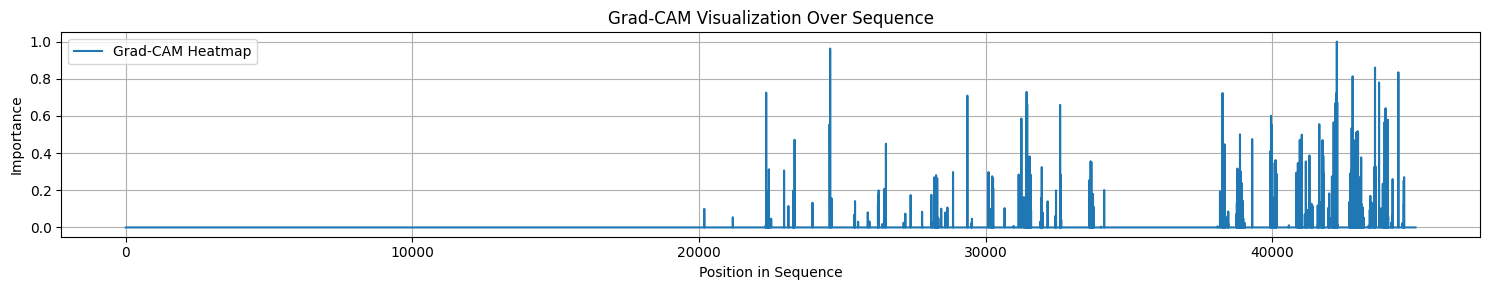

In [33]:
shift = 0
import matplotlib.pyplot as plt
import numpy as np
donor_idx = torch.nonzero(targets[2,:]).numpy() - shift
# gradcam_map is your 1D heatmap (shape: [45000])
plt.figure(figsize=(15, 3))
plt.plot(grad_cam[:], label='Grad-CAM Heatmap')
# plt.scatter(donor_idx, np.ones(len(donor_idx)),c='green',marker="^", clip_on=False, zorder=10,label='Donor')

plt.xlabel('Position in Sequence')
plt.ylabel('Importance')
plt.title('Grad-CAM Visualization Over Sequence')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

handle_forward.remove()
handle_backward.remove()
model_m.zero_grad()
for param in model_m.parameters():
    param.grad = None


### This section is what I initially used taking the average result from the 10 models for Grad-CAM. Can be skipped

In [18]:
from collections import OrderedDict
activations = []
gradients = []

# Hooks to capture activations and gradients
def forward_hook(model, input, output):
    activations.append(output)

def backward_hook(model, grad_input, grad_output):
    gradients.append(grad_output)
    

NUM_ACCUMULATION_STEPS = 1
temp = 1
n_models = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_m = SpliceFormer(CL_max,bn_momentum=0.01/NUM_ACCUMULATION_STEPS,depth=4,heads=4,n_transformer_blocks=2,determenistic=True,crop=False)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)
output_class_labels = ['Null', 'Acceptor', 'Donor']

#for output_class in [1,2]:
models = [copy.deepcopy(model_m) for i in range(n_models)]

if torch.cuda.device_count() > 1:
    [model.load_state_dict(torch.load('../Results/PyTorch_Models/transformer_encoder_45k_171022_{}'.format(i))) for i,model in enumerate(models)]
else:
    for i,model in enumerate(models):
        state_dict = torch.load('../Results/PyTorch_Models/transformer_encoder_45k_171022_{}'.format(i), map_location=device)
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k[7:] # remove `module.`
            new_state_dict[name] = v
        model.load_state_dict(new_state_dict)

for model in models:
    model.eval()


for i in range(n_models):
    # models[i].SpliceAI.res_layers[3].comboBlock[-1].register_forward_hook(forward_hook)
    # models[i].SpliceAI.res_layers[3].comboBlock[-1].register_full_backward_hook(backward_hook)
    models[i].SpliceAI.register_forward_hook(forward_hook)
    models[i].SpliceAI.register_full_backward_hook(backward_hook)



In [19]:
CL_max = 40000
SL = 5000
device = torch.device('cpu')
test_dataset = spliceDataset(getDataPointListFull(specific_anno,transcriptToLabel_test,SL,CL_max,shift=SL))
test_dataset.seqData = seqData
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
for i,(batch_chunks,target_chunks) in enumerate(tqdm(test_loader)):
    batch_features = batch_chunks.to(torch.float32).to(device)      # shape: [1, 4, 45000]
    targets = torch.squeeze(target_chunks.to(torch.float32).to(device), dim=0)  # shape: [3, 45000]
    
    signal = batch_features[0].sum(dim=0)  # shape: [45000]
    nonzero_positions = torch.nonzero(signal > 0).squeeze()
    print("Transcript spans:", nonzero_positions.min().item(), "to", nonzero_positions.max().item())

    if i == 4:
        break

  0%|          | 0/38 [00:00<?, ?it/s]/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
 11%|█         | 4/38 [00:00<00:00, 242.01it/s]

Transcript spans: 20000 to 44999
Transcript spans: 15000 to 44999
Transcript spans: 10000 to 44999
Transcript spans: 5000 to 44999
Transcript spans: 0 to 44999


In [154]:
def plot_single(grad_cam,model,label,idx):
    relu = torch.nn.ReLU()
    grad_cam = relu(grad_cam)
    grad_cam = grad_cam.detach().numpy()
    grad_cam /= grad_cam.max()
    plt.figure(figsize=(15, 3))
    plt.plot(grad_cam, label='Grad-CAM Heatmap')
    plt.scatter(idx, grad_cam[idx],c='green' if label==1 else 'red',marker="^", clip_on=False, zorder=10,label='Donor' if label==1 else 'Acceptor')

    plt.xlabel('Position in Sequence')
    plt.ylabel('Importance')
    plt.title(f'{model}-model Grad-CAM Visualization Over Sequence')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()

In [8]:
def skip_grad_cam(activations,gradients):
    avg_grad = torch.mean(gradients, dim=(0,2))
    activation_reduced = torch.mean(activations,dim=0)
    weighted_activations = avg_grad.unsqueeze(1) * activation_reduced
    grad_cam = torch.sum(weighted_activations,dim=0)
    return grad_cam

In [45]:
def plot_GradCAM_full(models, batch_features, targets, shift):
    grad_cam_dict = defaultdict(list)
    skip_grad_cam_dict = defaultdict(list)
    # grad_cam_full = []
    start,end = 0,45000
    start_shift = 20000
    for j,model in enumerate(models):
        acceptor_idxs = np.where(targets[1,:]==1)
        donor_idxs = np.where(targets[2,:]==1)
        splice_idxs = np.where(targets[1:,:]==1)
        activations.clear()
        gradients.clear()
        for label,idx in zip(splice_idxs[0],splice_idxs[1]):
            if idx not in (29071,24400):
                continue
            activations.clear()
            gradients.clear()
            output = model(batch_features)
            target = output[0][0,label+1,idx]
            model.zero_grad()
            target.backward()

            # test_act = model.SpliceAI.skip_combined['skip_combined_3']
            # test_grad = test_act.grad
            # skip_grad_cam_value = skip_grad_cam(test_act,test_grad)
            # skip_grad_cam_dict[idx].append(skip_grad_cam_value)

            avg_grad = torch.mean(gradients[0][0], dim=(0,2))
            activation_reduced = torch.mean(activations[0],dim=0)
            weighted_activations = avg_grad.unsqueeze(1) * activation_reduced
            grad_cam = torch.sum(weighted_activations, dim=0)
            # plot_single(grad_cam,j,label,idx)
            grad_cam_dict[idx].append(grad_cam)
            # break
    for label,key in zip(splice_idxs[0],splice_idxs[1]):
        if key not in (29071,24400):
            continue
        grad_cam_key = torch.stack(grad_cam_dict[key])
        grad_cam_key = torch.mean(grad_cam_key,dim=0)
        # grad_cam_key = grad_cam_key[1]
        relu = torch.nn.ReLU()
        grad_cam_key = relu(grad_cam_key)
        grad_cam_key = grad_cam_key.detach().numpy()
        if grad_cam_key.max()  != np.float32(0):
            grad_cam_key /= grad_cam_key.max()

        # skip_grad_cam_key = torch.stack(skip_grad_cam_dict[key])
        # skip_grad_cam_key = torch.mean(skip_grad_cam_key,dim=0)
        # skip_grad_cam_key = relu(skip_grad_cam_key)
        # skip_grad_cam_key = skip_grad_cam_key.detach().numpy()
        # if skip_grad_cam_key.max() != np.float32(0):
        #     skip_grad_cam_key /= skip_grad_cam_key.max()

        plt.figure(figsize=(15, 3))

        plt.plot(range(start+shift-start_shift,end+shift-start_shift),grad_cam_key, label='Grad-CAM Heatmap')
        if label == 1:
            plt.scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[donor_idxs], grad_cam_key[donor_idxs]+0.005,c='green',marker="^", clip_on=False, zorder=10,label='Donor')
        elif label == 0:
            plt.scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[acceptor_idxs], grad_cam_key[acceptor_idxs]+0.005,c='red',marker="^", clip_on=False, zorder=10,label='Acceptor')

        plt.scatter(key+shift-start_shift, grad_cam_key[key]+0.05,c='black',marker="v", clip_on=False, zorder=10,label='Selected')

        plt.xlabel('Position in Sequence')
        plt.ylabel('Grad-CAM score')
        plt.title('CFTR Gene Grad-CAM Visualization')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        if key in (29071,24400):
            plt.savefig(f'../Results/Grad-CAM/CFTR_Transformer_lastskip_{key}.png',dpi=600)
        plt.show()
        plt.close()

        plt.figure(figsize=(6, 6))
        plt.plot(range(start+shift-start_shift,end+shift-start_shift)[key-50:key+50],grad_cam_key[key-50:key+50], label='Grad-CAM Heatmap')
        if label == 1:
            plt.scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[key], grad_cam_key[key]+0.005,c='green',marker="^", clip_on=False, zorder=10,label='Donor')
        elif label == 0:
            plt.scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[key], grad_cam_key[key]+0.005,c='red',marker="^", clip_on=False, zorder=10,label='Acceptor')

        plt.scatter(key+shift-start_shift, grad_cam_key[key]+0.05,c='black',marker="v", clip_on=False, zorder=10,label='Selected')

        plt.xlabel('Position in Sequence')
        plt.ylabel('Grad-CAM score')
        plt.title('CFTR Gene Grad-CAM Visualization')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        if key == 29071:
            plt.savefig(f'../Results/Grad-CAM/CFTR_Transformer_lastskip_zoomed_{key}.png',dpi=600)
        plt.show()
        plt.close()
        # break
    return grad_cam_key

/var/folders/b4/wk8m28x57xn6sy326ngv7k5m0000gn/T/ipykernel_21718/4278985921.py:21: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  target.backward()


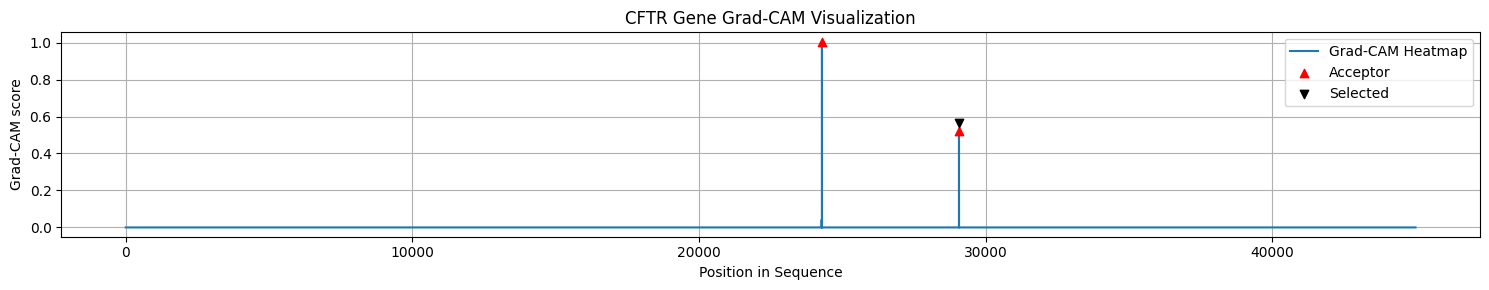

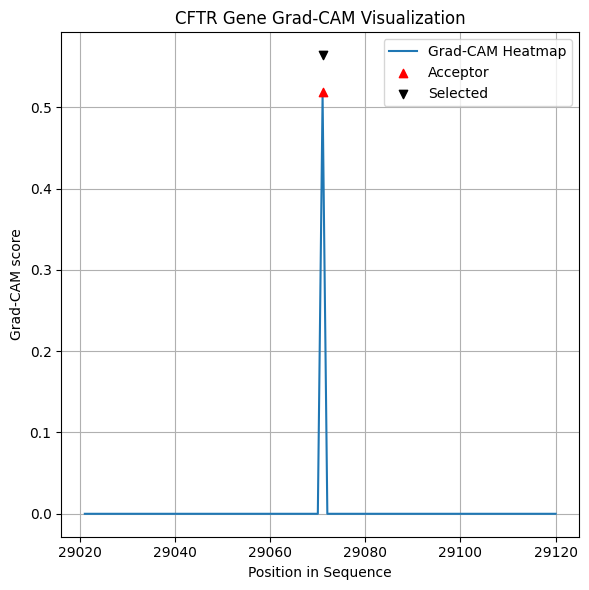

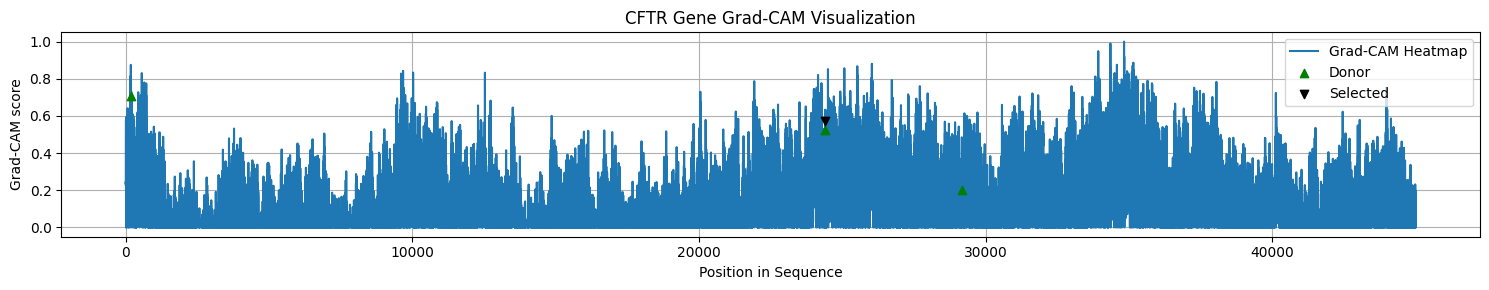

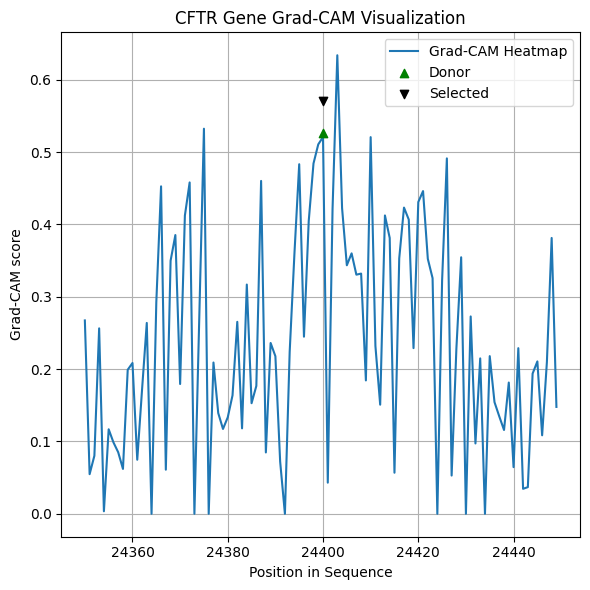

array([0.2302371 , 0.24619187, 0.23922873, ..., 0.00984039, 0.        ,
       0.        ], dtype=float32)

In [46]:
plot_GradCAM_full(models,batch_features,targets,20000)

### This section includes some preliminary tests of Grad-CAM for SpliceAI, using an earlier version of the function. Can be skipped

In [91]:
from collections import OrderedDict
activations = []
gradients = []

# Hooks to capture activations and gradients
def forward_hook(model, input, output):
    activations.append(output)

def backward_hook(model, grad_input, grad_output):
    gradients.append(grad_output)

CL_max=10000
SL=5000

NUM_ACCUMULATION_STEPS = 1
temp = 1
n_models = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_m = SpliceAI_10K(CL_max,crop=False)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)

output_class_labels = ['Null', 'Acceptor', 'Donor']

#for output_class in [1,2]:
models = [copy.deepcopy(model_m) for i in range(n_models)]

if torch.cuda.device_count() > 1:
    [model.load_state_dict(torch.load('../Results/PyTorch_Models/spliceai_encoder_10k_191022_{}'.format(i))) for i,model in enumerate(models)]
else:
    for i,model in enumerate(models):
        state_dict = torch.load('../Results/PyTorch_Models/spliceai_encoder_10k_191022_{}'.format(i), map_location=device)
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k[7:] # remove `module.`
            new_state_dict[name] = v
        model.load_state_dict(new_state_dict)

for model in models:
    model.eval()


for i in range(n_models):
    # models[i].feature_tap.register_forward_hook(forward_hook)
    # models[i].feature_tap.register_full_backward_hook(backward_hook)
    models[i].feature_tap.register_forward_hook(forward_hook)
    models[i].feature_tap.register_full_backward_hook(backward_hook)


In [92]:
CL_max = 10000
SL = 5000
device = torch.device('cpu')
test_dataset = spliceDataset(getDataPointListFull(specific_anno,transcriptToLabel_test,SL,CL_max,shift=SL))
test_dataset.seqData = seqData
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
for i,(batch_chunks,target_chunks) in enumerate(tqdm(test_loader)):
    batch_features = batch_chunks.to(torch.float32).to(device)      # shape: [1, 4, 45000]
    targets = torch.squeeze(target_chunks.to(torch.float32).to(device), dim=0)  # shape: [3, 45000]
    
    signal = batch_features[0].sum(dim=0)  # shape: [45000]
    nonzero_positions = torch.nonzero(signal > 0).squeeze()
    print("Transcript spans:", nonzero_positions.min().item(), "to", nonzero_positions.max().item())

    if i == 4:
        break

  0%|          | 0/38 [00:00<?, ?it/s]/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
 11%|█         | 4/38 [00:00<00:00, 234.91it/s]

Transcript spans: 5000 to 14999
Transcript spans: 0 to 14999
Transcript spans: 0 to 14999
Transcript spans: 0 to 14999
Transcript spans: 0 to 14999


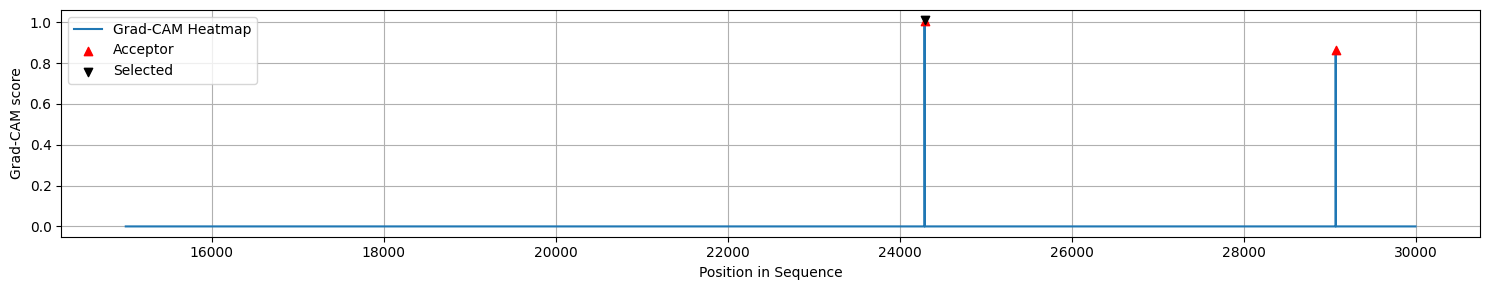

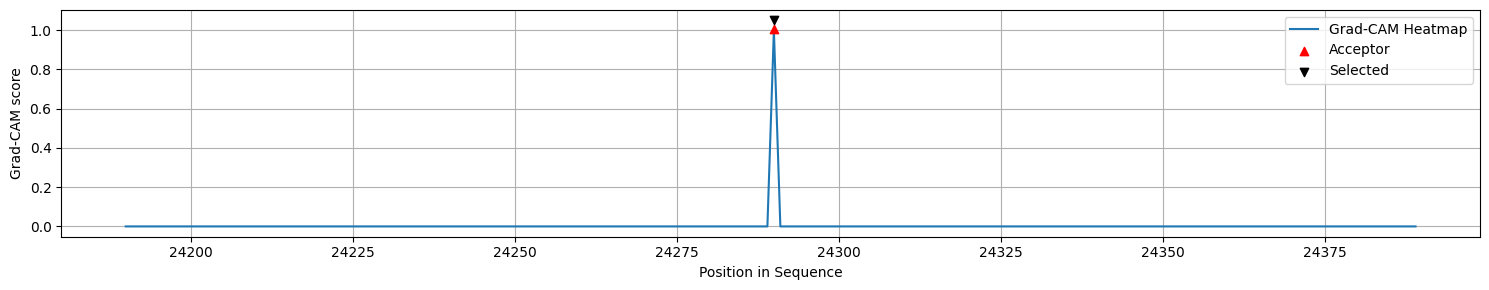

In [63]:
skip_final = plot_GradCAM_full(models,batch_features,targets,20000)

### This section has the most recent version of the function I have for calculating and plotting Grad-CAM. Used to look at multiple layers 

In [10]:
# This function is used to calculate grad-cam for the skip connections
def skip_grad_cam(activations,gradients):
    avg_grad = torch.mean(gradients, dim=(0,2))
    activation_reduced = torch.mean(activations,dim=0)
    weighted_activations = avg_grad.unsqueeze(1) * activation_reduced
    grad_cam = torch.sum(weighted_activations,dim=0)
    return grad_cam

When looking at the skip connections, I added an additional self.skip_combined = {} term in the models __init__. Then during the forward() function I set self.skip_combined[f'skip_combined_{i}'] = combined. I had to do it this way as I couldn't access these skip connections by placing forward and backward hooks like I could for the res_layer. I added this skip_combined option for both Transformer-40k and SpliceAI_10k.

In [4]:
# LOADING TRANSFORMER MODEL

from collections import OrderedDict
activations = {}
gradients = {}

# Define functions for hooks

def get_layer_key(i,layer_name):
    return f"model{i}_{layer_name}"

def make_forward_hook(i, layer_name):
    def forward_hook(model, input, output):
        activations[get_layer_key(i, layer_name)] = output
    return forward_hook

def make_backward_hook(i, layer_name):
    def backward_hook(model, grad_input, grad_output):
        gradients[get_layer_key(i, layer_name)] = grad_output
    return backward_hook

CL_max=40000
SL=5000

NUM_ACCUMULATION_STEPS = 1
temp = 1
n_models = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_m = SpliceFormer(CL_max,bn_momentum=0.01/NUM_ACCUMULATION_STEPS,depth=4,heads=4,n_transformer_blocks=2,determenistic=True,crop=False)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)

#for output_class in [1,2]:
models = [copy.deepcopy(model_m) for i in range(n_models)]

if torch.cuda.device_count() > 1:
    [model.load_state_dict(torch.load('../Results/PyTorch_Models/transformer_encoder_45k_171022_{}'.format(i))) for i,model in enumerate(models)]
else:
    for i,model in enumerate(models):
        state_dict = torch.load('../Results/PyTorch_Models/transformer_encoder_45k_171022_{}'.format(i), map_location=device)
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k[7:] # remove `module.`
            new_state_dict[name] = v
        model.load_state_dict(new_state_dict)

for model in models:
    model.eval()


for i in range(n_models):
    # final_layer = models[i].SpliceAI
    # final_res_layer = models[i].SpliceAI.res_layers[3].comboBlock[3]
    # final_layer.register_forward_hook(make_forward_hook(i, 'Final_Layer'))
    # final_layer.register_full_backward_hook(make_backward_hook(i, 'Final_Layer'))

    # final_res_layer.register_forward_hook(make_forward_hook(i, 'Final_Residual_Block'))
    # final_res_layer.register_full_backward_hook(make_backward_hook(i, 'Final_Residual_Block'))
    for j in range(4):
        models[i].SpliceAI.res_layers[j].register_forward_hook(make_forward_hook(i, f'res_layer_{j}'))
        models[i].SpliceAI.res_layers[j].register_full_backward_hook(make_backward_hook(i, f'res_layer_{j}'))

In [4]:
# LOADING SPLICEAI MODEL

from collections import OrderedDict
activations = {}
gradients = {}


# Define functions for hooks

def get_layer_key(i,layer_name):
    return f"model{i}_{layer_name}"

def make_forward_hook(i, layer_name):
    def forward_hook(model, input, output):
        activations[get_layer_key(i, layer_name)] = output
    return forward_hook

def make_backward_hook(i, layer_name):
    def backward_hook(model, grad_input, grad_output):
        gradients[get_layer_key(i, layer_name)] = grad_output
    return backward_hook

CL_max=10000
SL=5000

NUM_ACCUMULATION_STEPS = 1
temp = 1
n_models = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_m = SpliceAI_10K(CL_max,crop=False)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)

output_class_labels = ['Null', 'Acceptor', 'Donor']

#for output_class in [1,2]:
models = [copy.deepcopy(model_m) for i in range(n_models)]

if torch.cuda.device_count() > 1:
    [model.load_state_dict(torch.load('../Results/PyTorch_Models/spliceai_encoder_10k_191022_{}'.format(i))) for i,model in enumerate(models)]
else:
    for i,model in enumerate(models):
        state_dict = torch.load('../Results/PyTorch_Models/spliceai_encoder_10k_191022_{}'.format(i), map_location=device)
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k[7:] # remove `module.`
            new_state_dict[name] = v
        model.load_state_dict(new_state_dict)

for model in models:
    model.eval()


for i in range(n_models):
    for j in range(4):
        models[i].res_layers[j].register_forward_hook(make_forward_hook(i, f'res_layer_{j}'))
        models[i].res_layers[j].register_full_backward_hook(make_backward_hook(i, f'res_layer_{j}'))

Once again we are looking at the CFTR gene, and looking at a specific part in the sequence for testing.

In [16]:

device = torch.device('cpu')
test_dataset = spliceDataset(getDataPointListFull(specific_anno,transcriptToLabel_test,SL,CL_max,shift=SL))
test_dataset.seqData = seqData
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
for i,(batch_chunks,target_chunks) in enumerate(tqdm(test_loader)):
    batch_features = batch_chunks.to(torch.float32).to(device)      # shape: [1, 4, 45000]
    targets = torch.squeeze(target_chunks.to(torch.float32).to(device), dim=0)  # shape: [3, 45000]
    
    signal = batch_features[0].sum(dim=0)  # shape: [45000]
    nonzero_positions = torch.nonzero(signal > 0).squeeze()
    print("Transcript spans:", nonzero_positions.min().item(), "to", nonzero_positions.max().item())

    if i == 4:
        break

  0%|          | 0/38 [00:00<?, ?it/s]/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
 11%|█         | 4/38 [00:00<00:00, 564.32it/s]

Transcript spans: 5000 to 14999
Transcript spans: 0 to 14999
Transcript spans: 0 to 14999
Transcript spans: 0 to 14999
Transcript spans: 0 to 14999


This plot_GradCAM_multilayer() function was initally used to save and plot the grad_cam results for multiple layers in a model, but now just saves it as plotting was moved to its own function

In [8]:
def default_inner_dict():
    return defaultdict(list)

def plot_GradCAM_multilayer(models, batch_features, targets, shift, type):
    grad_cam_dict = defaultdict(default_inner_dict)
    # start,end = 0,15000
    # start_shift = 5000
    for j,model in enumerate(models):
        if type == 'SpliceAI':
            targets = targets[:,CL_max//2:-CL_max//2]
        # acceptor_idxs = np.where(targets[1,:]==1)
        # donor_idxs = np.where(targets[2,:]==1)
        splice_idxs = np.where(targets[1:,:]==1)
        activations.clear()
        gradients.clear()
        for label,idx in zip(splice_idxs[0],splice_idxs[1]):
            for layer in ['skip_combined_0','skip_combined_1','skip_combined_2','skip_combined_3']: #['skip_combined_0','skip_combined_1','skip_combined_2','skip_combined_3'] ['res_layer_0','res_layer_1','res_layer_2','res_layer_3']
                activations.clear()
                gradients.clear()
                output = model(batch_features)
                target = output[0][0,label+1,idx] if type == 'Spliceformer' else output[0,label+1,idx]
                model.zero_grad()
                target.backward()
                if layer in ['res_layer_0','res_layer_1','res_layer_2','res_layer_3']:
                    key = get_layer_key(j,layer)
                    A = activations[key]
                    G = gradients[key]
                    avg_grad = torch.mean(G[0], dim=(0,2)) # These steps are basically doing the same thing as skip_grad_cam, just not packaged in a function
                    activation_reduced = torch.mean(A,dim=0)
                    weighted_activations = avg_grad.unsqueeze(1) * activation_reduced
                    grad_cam = torch.sum(weighted_activations, dim=0)
                    grad_cam_dict[idx][layer].append(grad_cam)
                else:
                    test_act = model.SpliceAI.skip_combined[layer] if type == 'Spliceformer' else model.skip_combined[layer]
                    test_grad = test_act.grad
                    grad_cam_dict[idx][layer].append(skip_grad_cam(test_act,test_grad))

        if not os.path.exists('../Results/Grad-CAM/'):
            os.makedirs('../Results/Grad-CAM/')
        with open('../Results/Grad-CAM/CFTR_SpliceAI10k_skips_4.pkl','wb') as f:
            pickle.dump(grad_cam_dict,f)


    # Was initally plotting in same function

    # for label,key in zip(splice_idxs[0],splice_idxs[1]):
    #     plt.figure(figsize=(15, 3))
    #     for layer in grad_cam_dict[key]:
    #         grad_cam_key = torch.stack(grad_cam_dict[key][layer])
    #         grad_cam_key = torch.mean(grad_cam_key,dim=0)
    #         relu = torch.nn.ReLU()
    #         grad_cam_key = relu(grad_cam_key)
    #         grad_cam_key = grad_cam_key.detach().numpy()
    #         if grad_cam_key.max()  != np.float32(0):
    #             grad_cam_key /= grad_cam_key.max()

    #         plt.plot(range(start+shift-start_shift,end+shift-start_shift),grad_cam_key, label=layer)
        
    #     if label == 1:
    #         plt.scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[donor_idxs], np.ones(len(donor_idxs[0])),c='green',marker="^", clip_on=False, zorder=10,label='Donor')
    #     elif label == 0:
    #         plt.scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[acceptor_idxs], np.ones(len(acceptor_idxs[0])),c='red',marker="^", clip_on=False, zorder=10,label='Acceptor')

    #     plt.scatter(key+shift-start_shift, np.ones(1)+0.01,c='black',marker="v", clip_on=False, zorder=10,label='Selected')

    #     plt.xlabel('Position in Sequence')
    #     plt.ylabel('Grad-CAM score')
    #     plt.title('CFTR Gene Grad-CAM Visualization')
    #     plt.legend()
    #     plt.grid(True)
    #     plt.tight_layout()
    #     plt.show()
    #     plt.close()

In [11]:
plot_GradCAM_multilayer(models,batch_features,targets,20000,type='SpliceAI')

This function plotter() is used to plot the saved grad_cam results in .pkl format. Note that because of how both Transformer-40k and SpliceAI_10k process transcripts (with a moving 5,000 middle predictive region), you need to keep track of the 5000 shift that occurs at each iteration. Additionally, sequences have an additional 'start_shift', because the 5,000 nt region of interest is always in the middle of the input sequence. So for Transformer-40k the first iteration has the first 5,000 nt in the middle of the 45,000 nt input sequence. This means the first 20,000 nt is zero-padded, hence a start_shift of 20000. The same is true with SpliceAI_10k except with a 5,000 start_shift.

In [23]:
def plotter(targets,path):
    with open(path, 'rb') as f:
        grad_cam_dict = pickle.load(f)

    acceptor_idxs = np.where(targets[1,:]==1)
    donor_idxs = np.where(targets[2,:]==1)
    splice_idxs = np.where(targets[1:,:]==1)
    start,end = 0,15000
    start_shift = 5000
    shift = 20000
    for label,key in zip(splice_idxs[0],splice_idxs[1]):
        print(key)
        fig, axs = plt.subplots(4, figsize=(22,12),sharex=True, sharey=True)
        default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]


        for i,layer in enumerate(grad_cam_dict[key]):
            grad_cam_key = torch.stack(grad_cam_dict[key][layer])
            grad_cam_key = torch.mean(grad_cam_key,dim=0)
            relu = torch.nn.ReLU()
            grad_cam_key = relu(grad_cam_key)
            grad_cam_key = grad_cam_key.detach().numpy()
            if grad_cam_key.max()  != np.float32(0):
                grad_cam_key /= grad_cam_key.max()

            colors = list(reversed(default_colors[:4]))
            axs[i].plot(range(start+shift-start_shift,end+shift-start_shift)[:],grad_cam_key[:], label=layer, color=colors[i % len(colors)])
            # axs[i].set_xlim(-1500,2000)
            if label == 1:
                axs[i].scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[donor_idxs], grad_cam_key[donor_idxs]+0.005,c='green',marker="^", clip_on=False, zorder=10,label='Donor')
            elif label == 0:
                axs[i].scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[acceptor_idxs], grad_cam_key[acceptor_idxs]+0.005,c='red',marker="^", clip_on=False, zorder=10,label='Acceptor')


            axs[i].scatter(key+shift-start_shift, grad_cam_key[key]+0.05,c='black',marker="v", clip_on=False, zorder=10,label='Selected')

            axs[i].legend(loc='upper right')
        fig.supxlabel('Position in Sequence')
        fig.supylabel('Grad-CAM score')
        fig.suptitle('CFTR Gene Grad-CAM Visualization')

        fig.set_constrained_layout(True)
        if key in (9290,9400):
            plt.savefig(f'../Results/Grad-CAM/CFTR Gene SpliceAI Grad-CAM skip layers {key}',dpi=600)
        plt.show()
        plt.close()

    for label,key in zip(splice_idxs[0],splice_idxs[1]):
        fig, axs = plt.subplots(4, figsize=(22,12),sharex=True, sharey=True)
        colors = plt.rcParams["axes.prop_cycle"]()

        for i,layer in enumerate(grad_cam_dict[key]):
            grad_cam_key = torch.stack(grad_cam_dict[key][layer])
            grad_cam_key = torch.mean(grad_cam_key,dim=0)
            relu = torch.nn.ReLU()
            grad_cam_key = relu(grad_cam_key)
            grad_cam_key = grad_cam_key.detach().numpy()
            if grad_cam_key.max()  != np.float32(0):
                grad_cam_key /= grad_cam_key.max()

            c = next(colors)["color"]
            axs[i].plot(range(start+shift-start_shift,end+shift-start_shift)[key-100:key+100],grad_cam_key[key-100:key+100], label=layer, color=c)
            if label == 1:
                axs[i].scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[key], 1,c='green',marker="^", clip_on=False, zorder=10,label='Donor')
            elif label == 0:
                axs[i].scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[key], 1,c='red',marker="^", clip_on=False, zorder=10,label='Acceptor')


            axs[i].scatter(key+shift-start_shift, 1+0.01,c='black',marker="v", clip_on=False, zorder=10,label='Selected')

            axs[i].legend(loc='upper right')
        fig.supxlabel('Position in Sequence')
        fig.supylabel('Grad-CAM score')
        fig.suptitle('CFTR Gene Grad-CAM Visualization')

        fig.set_constrained_layout(True)
        plt.show()
        plt.close()

9290


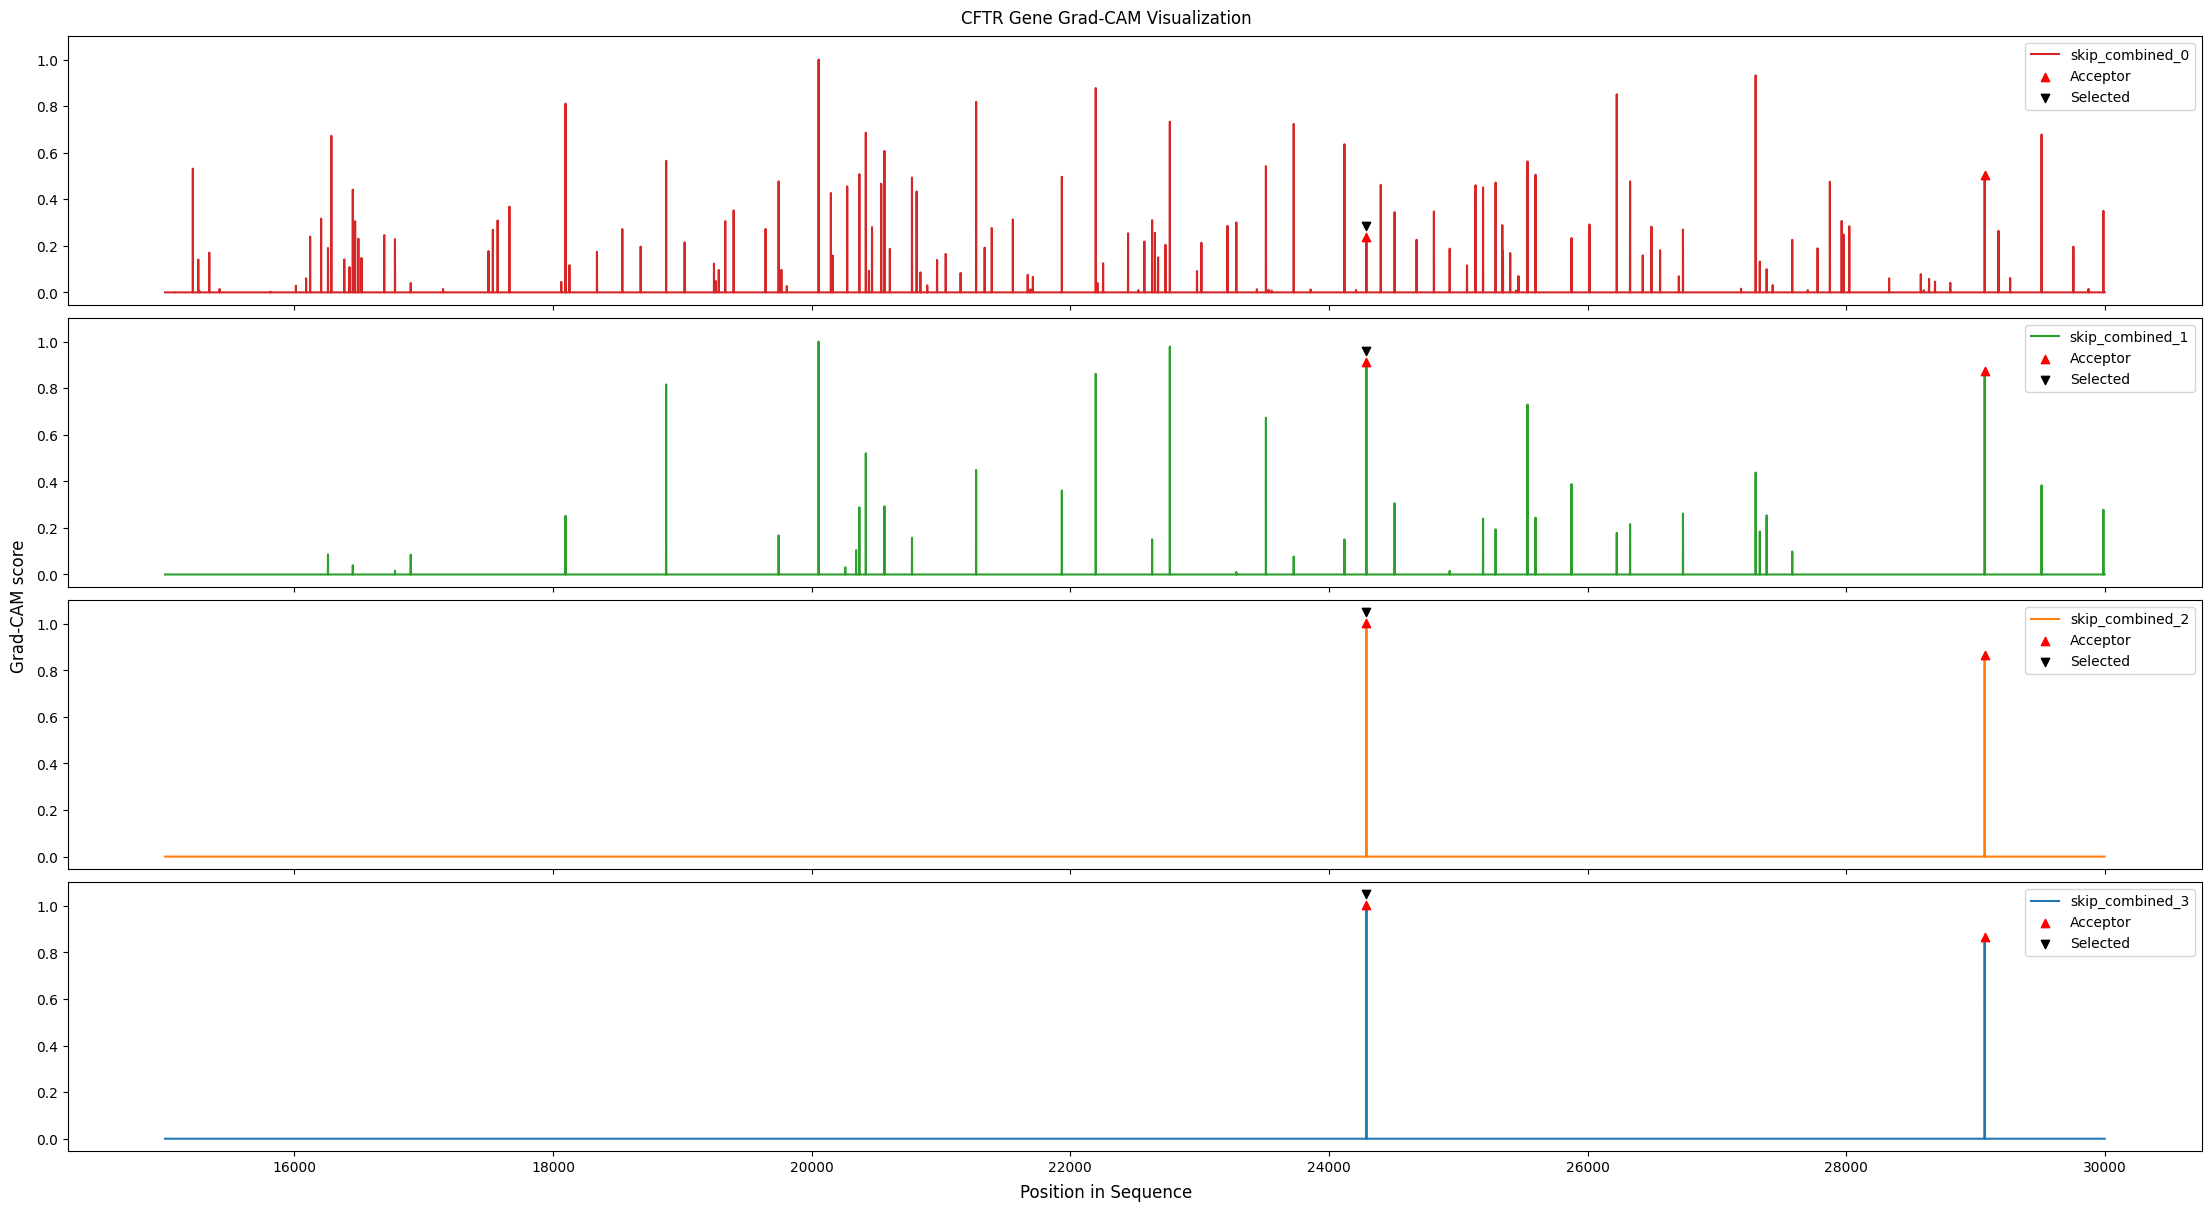

14071


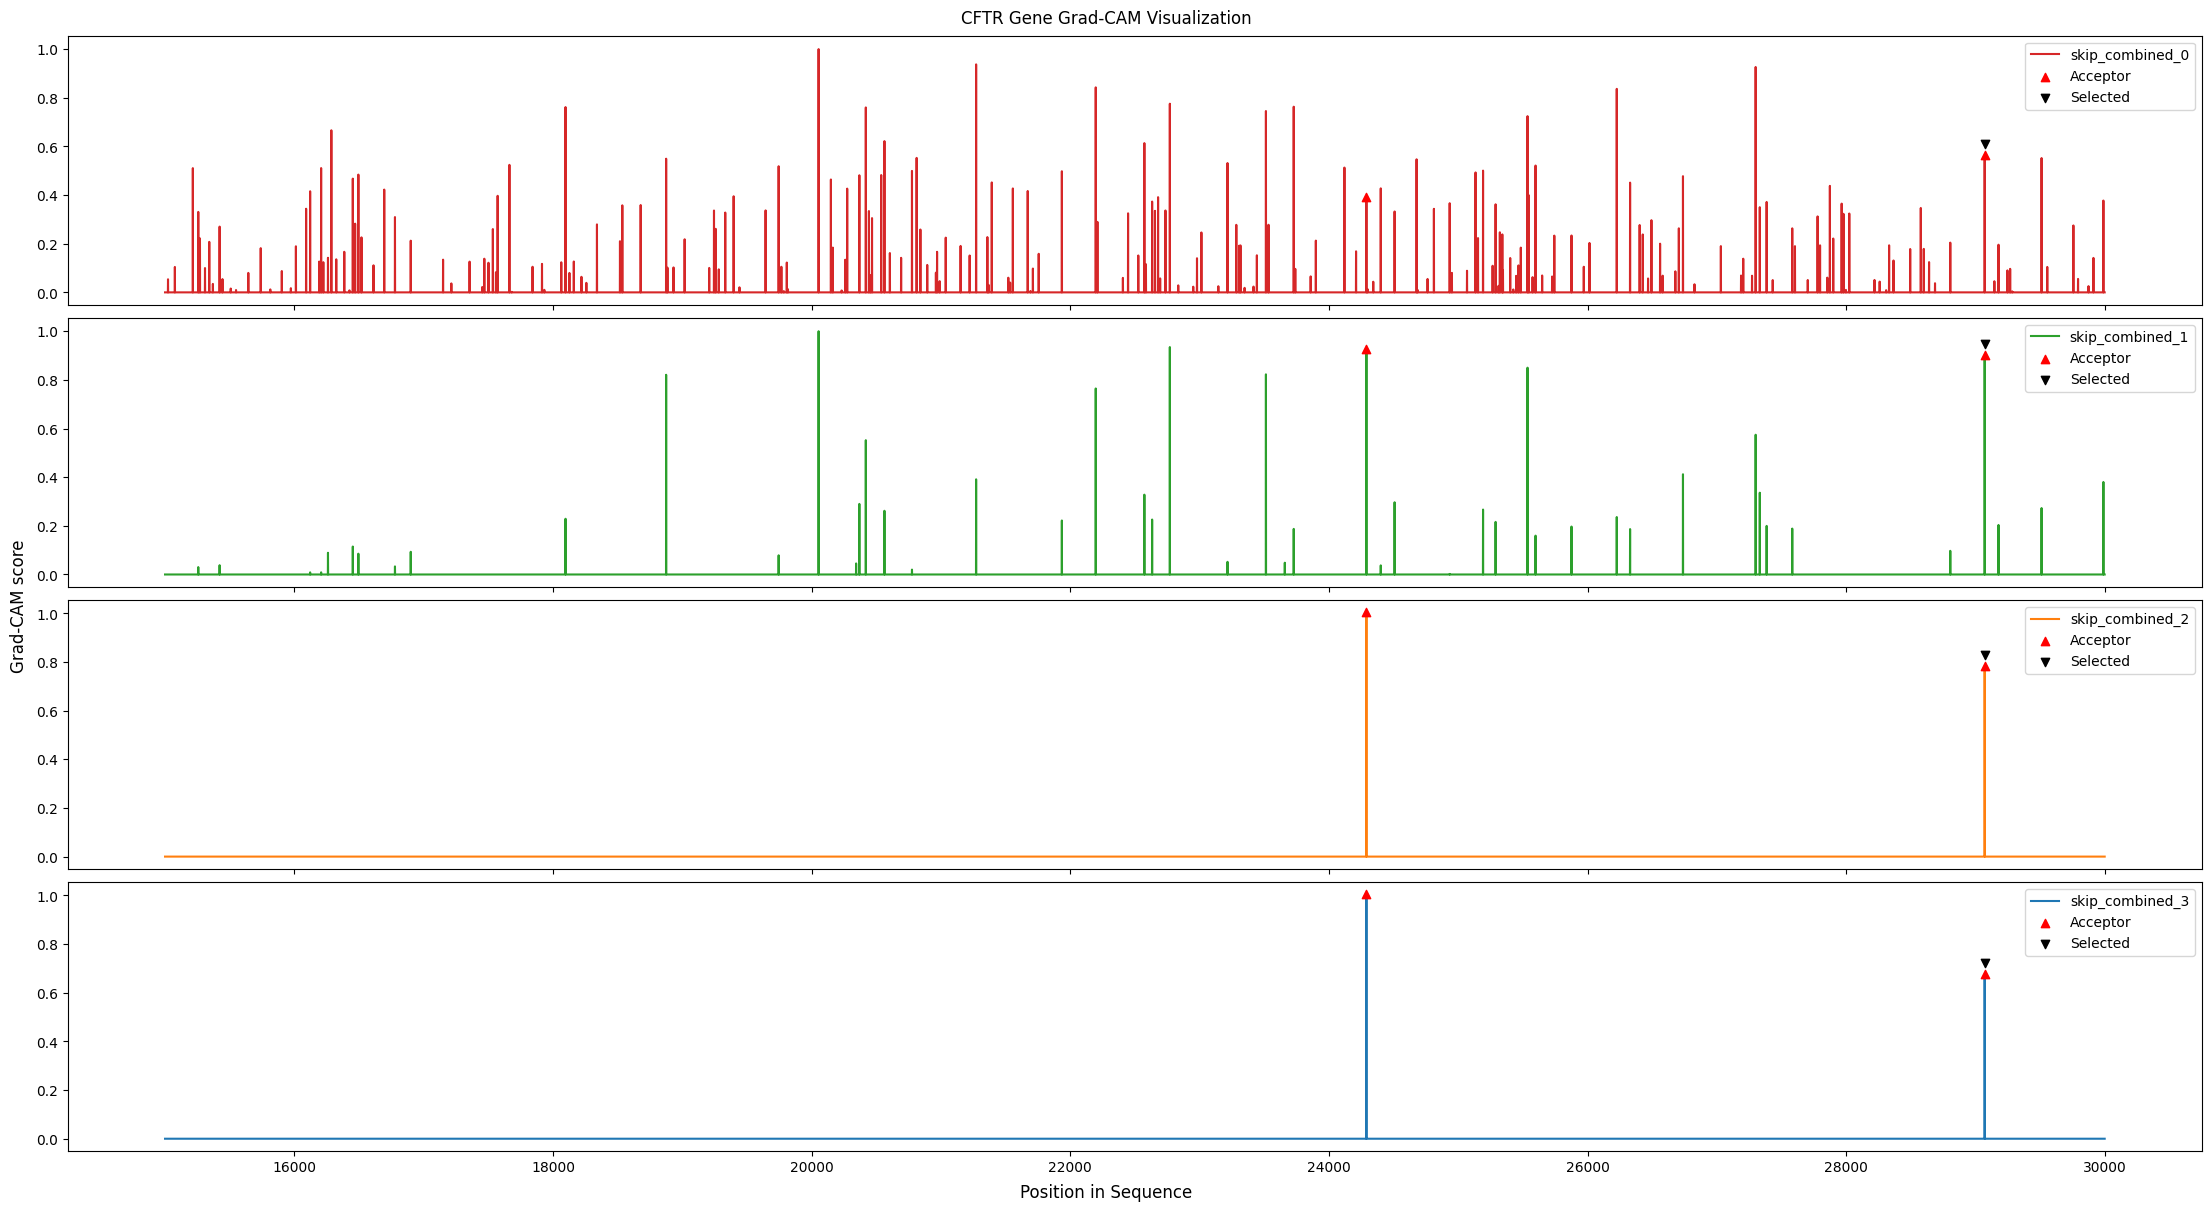

9400


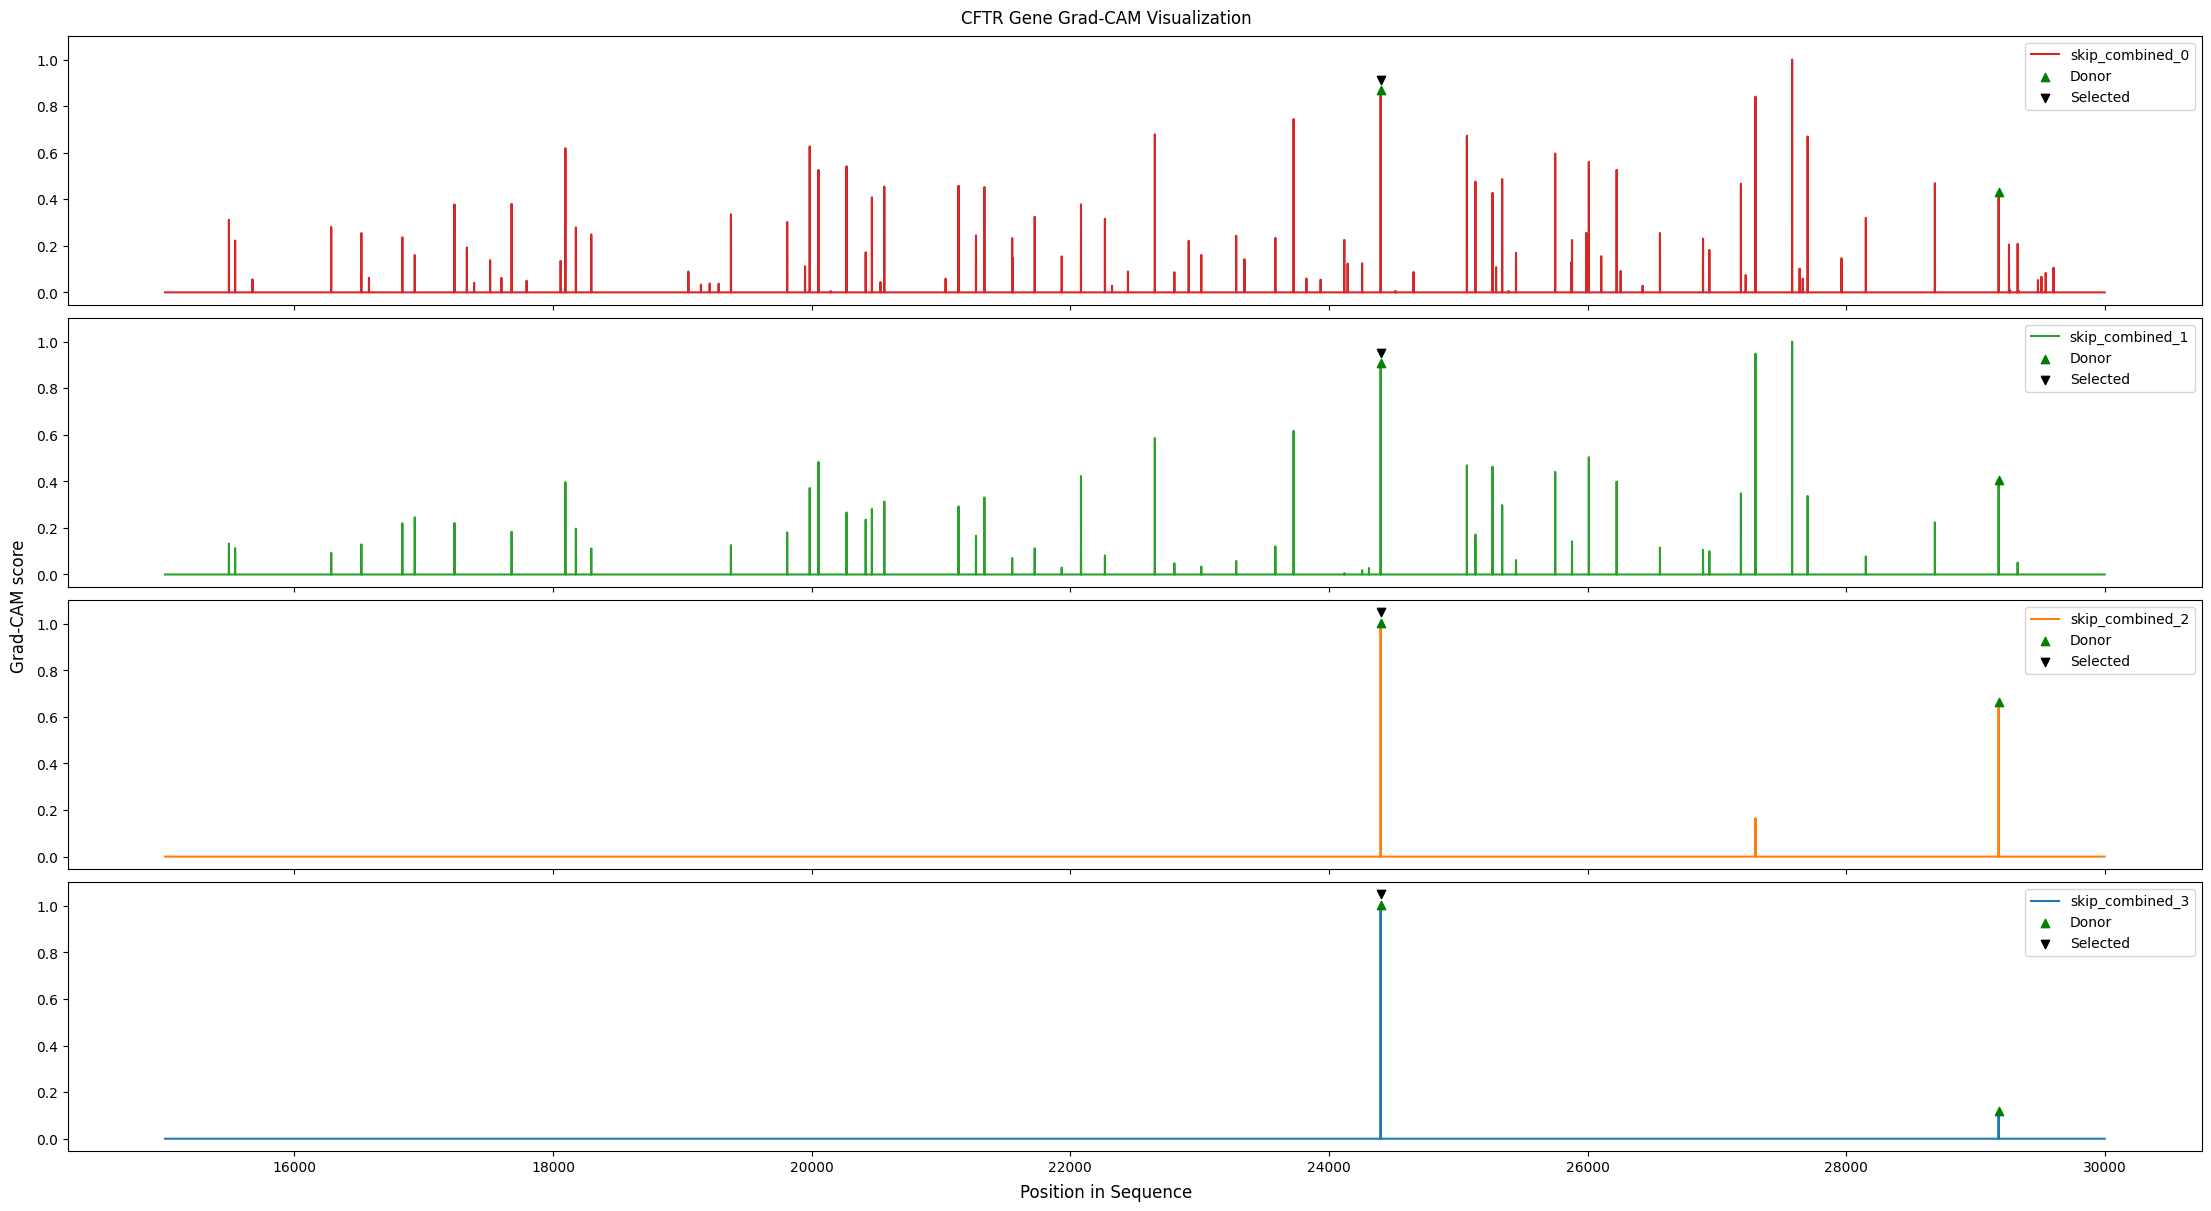

14179


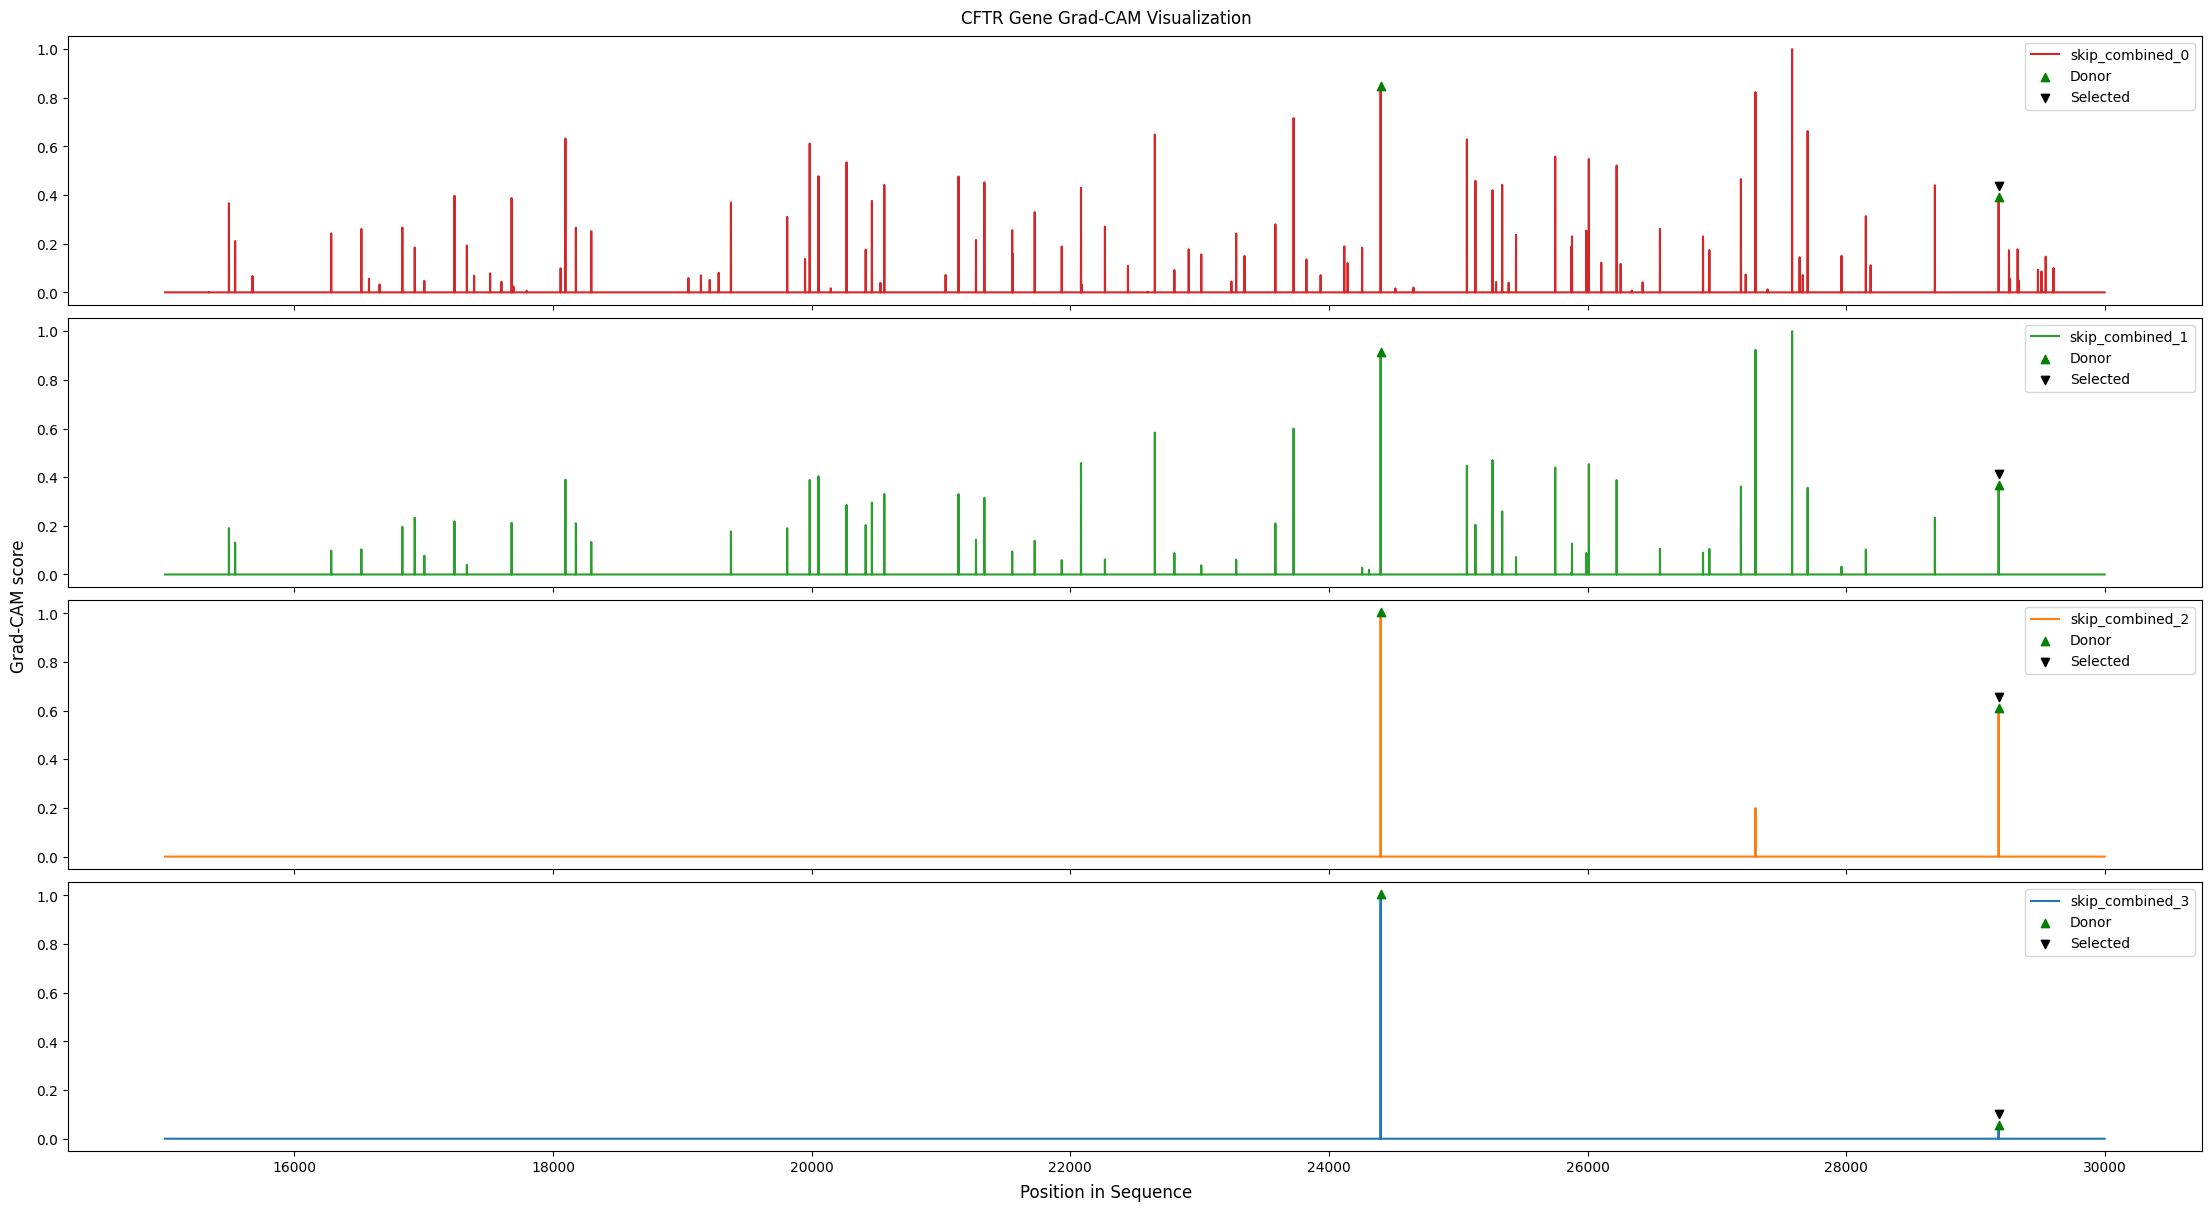

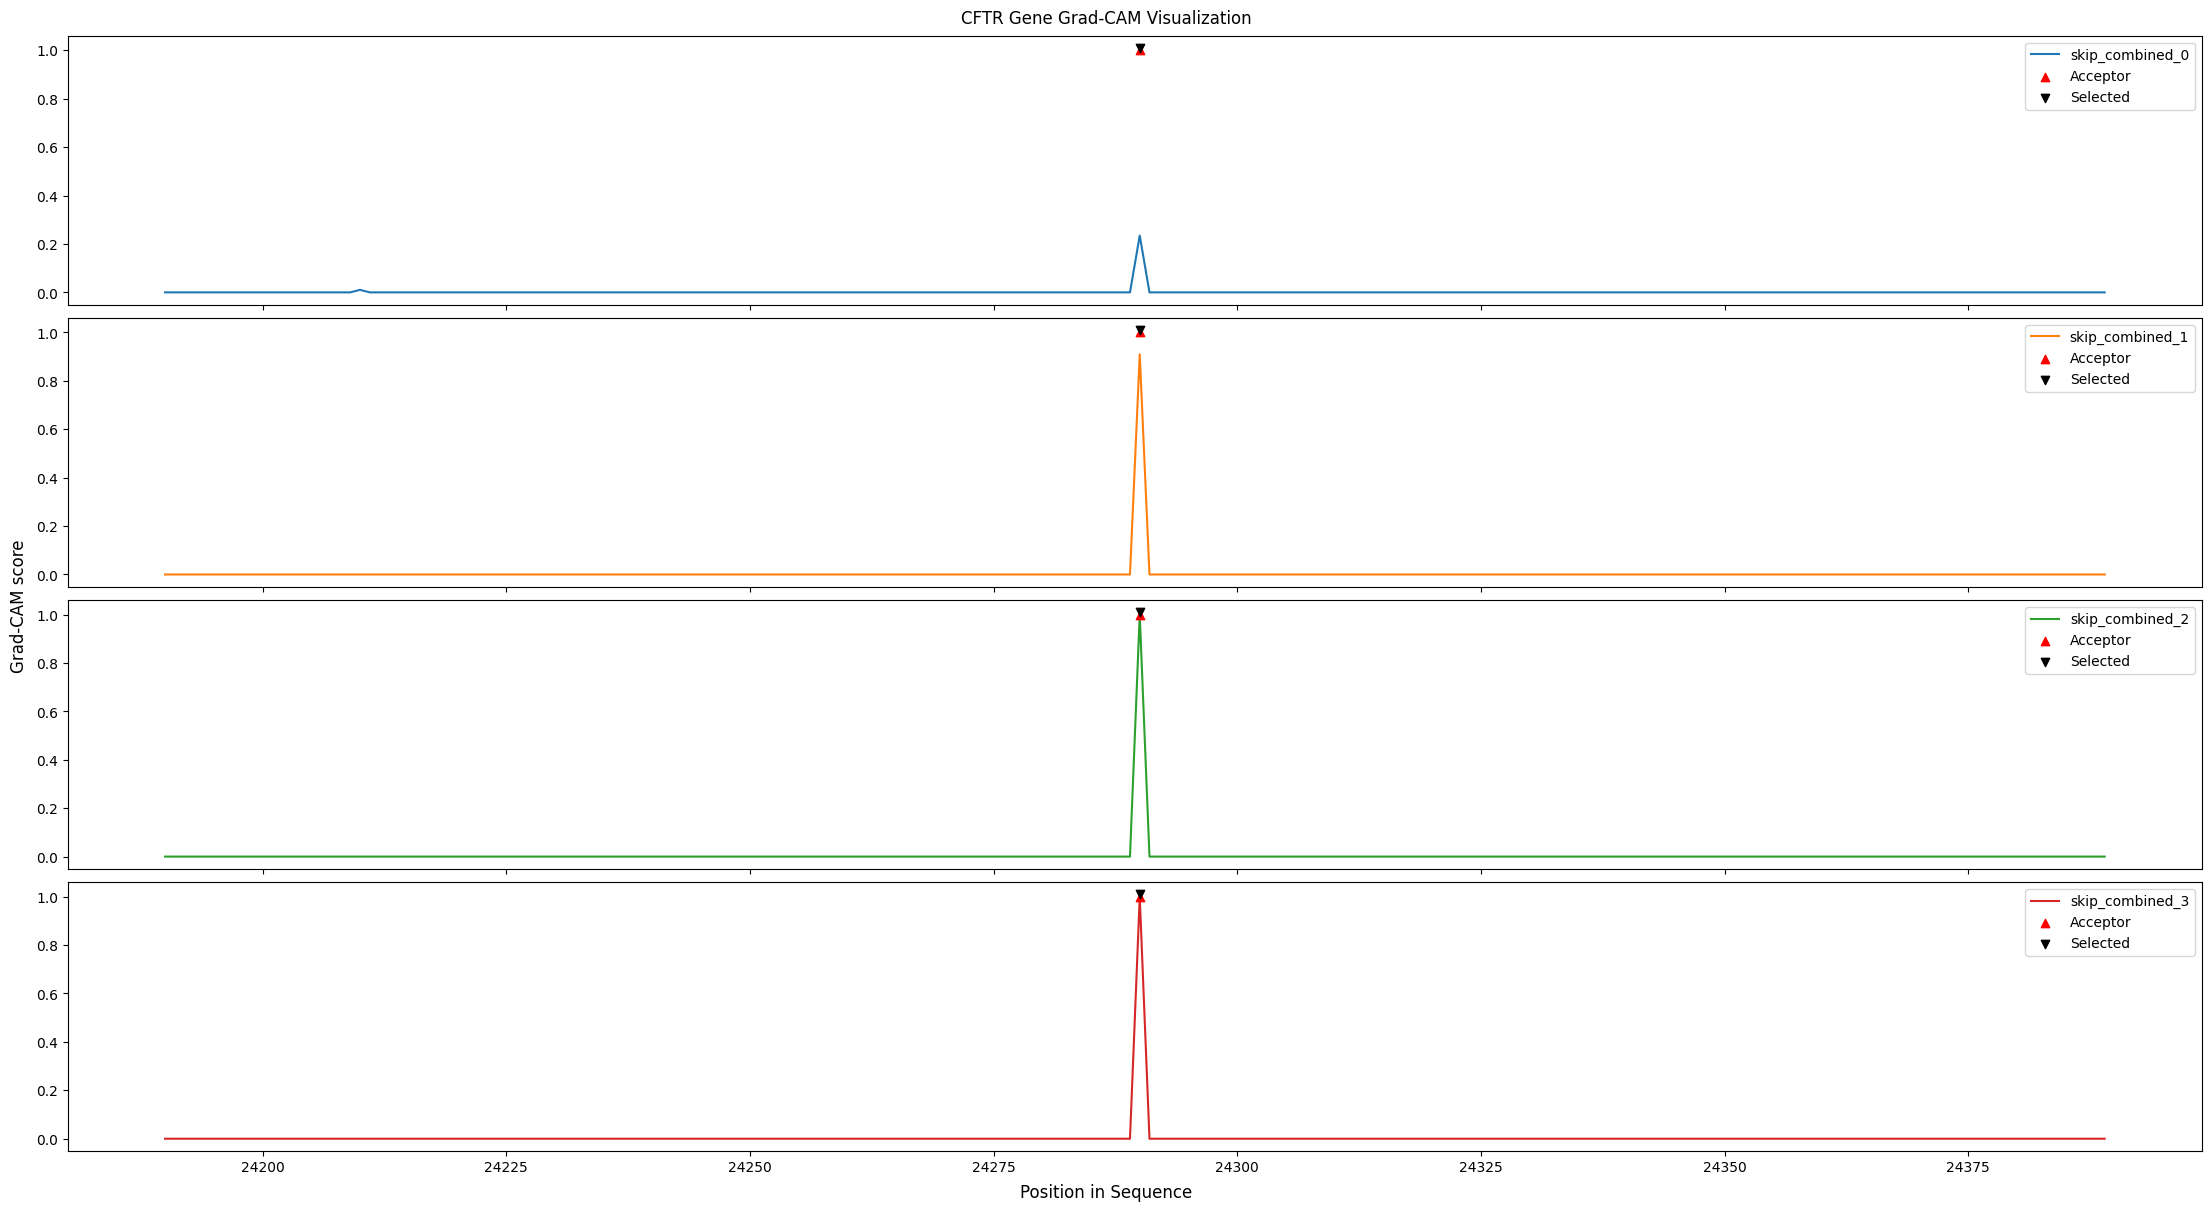

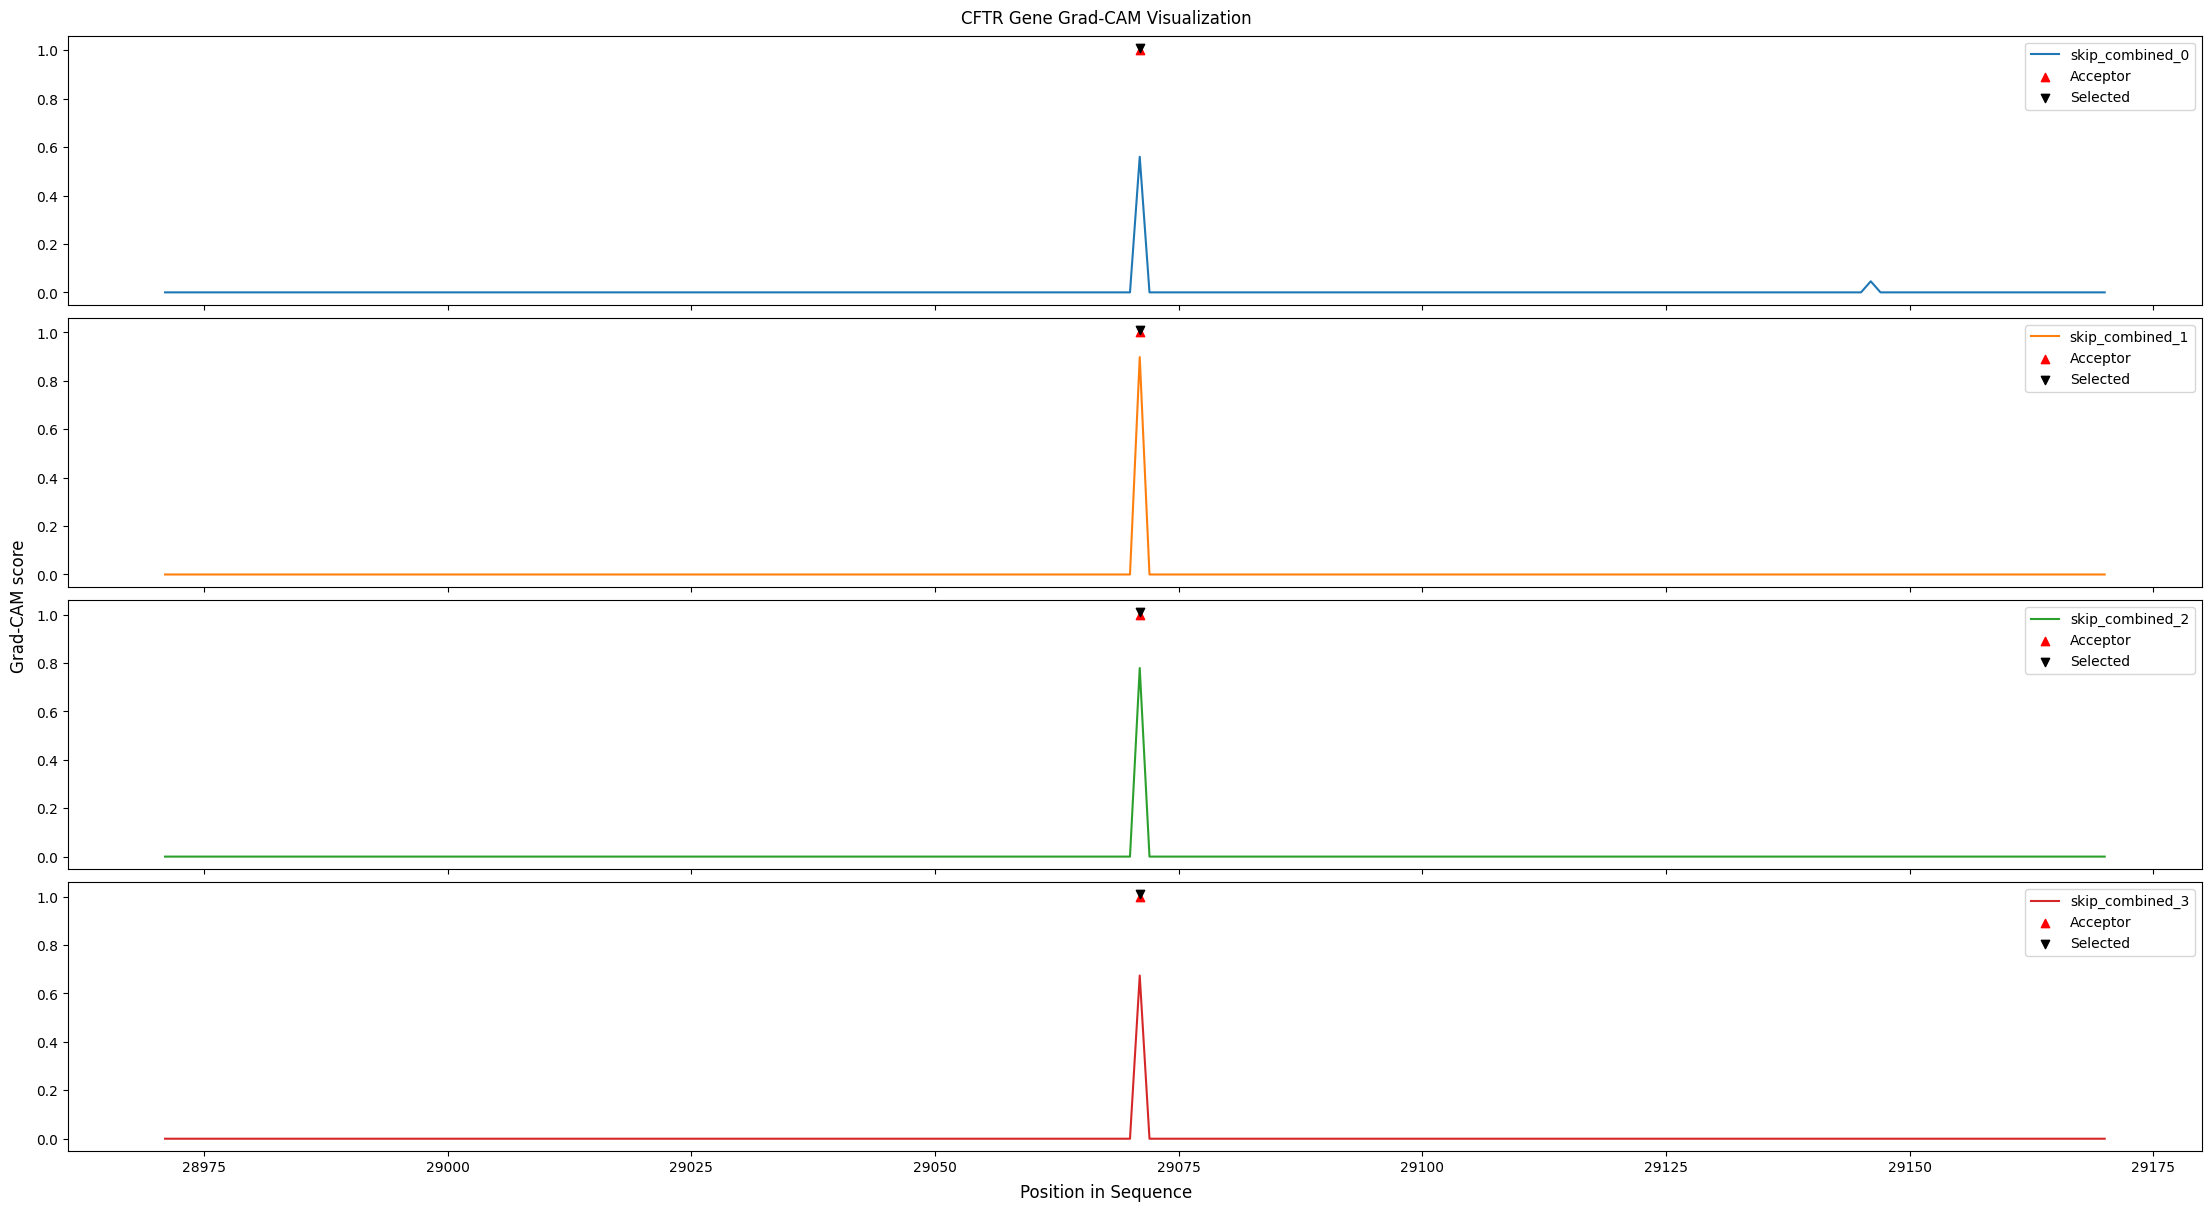

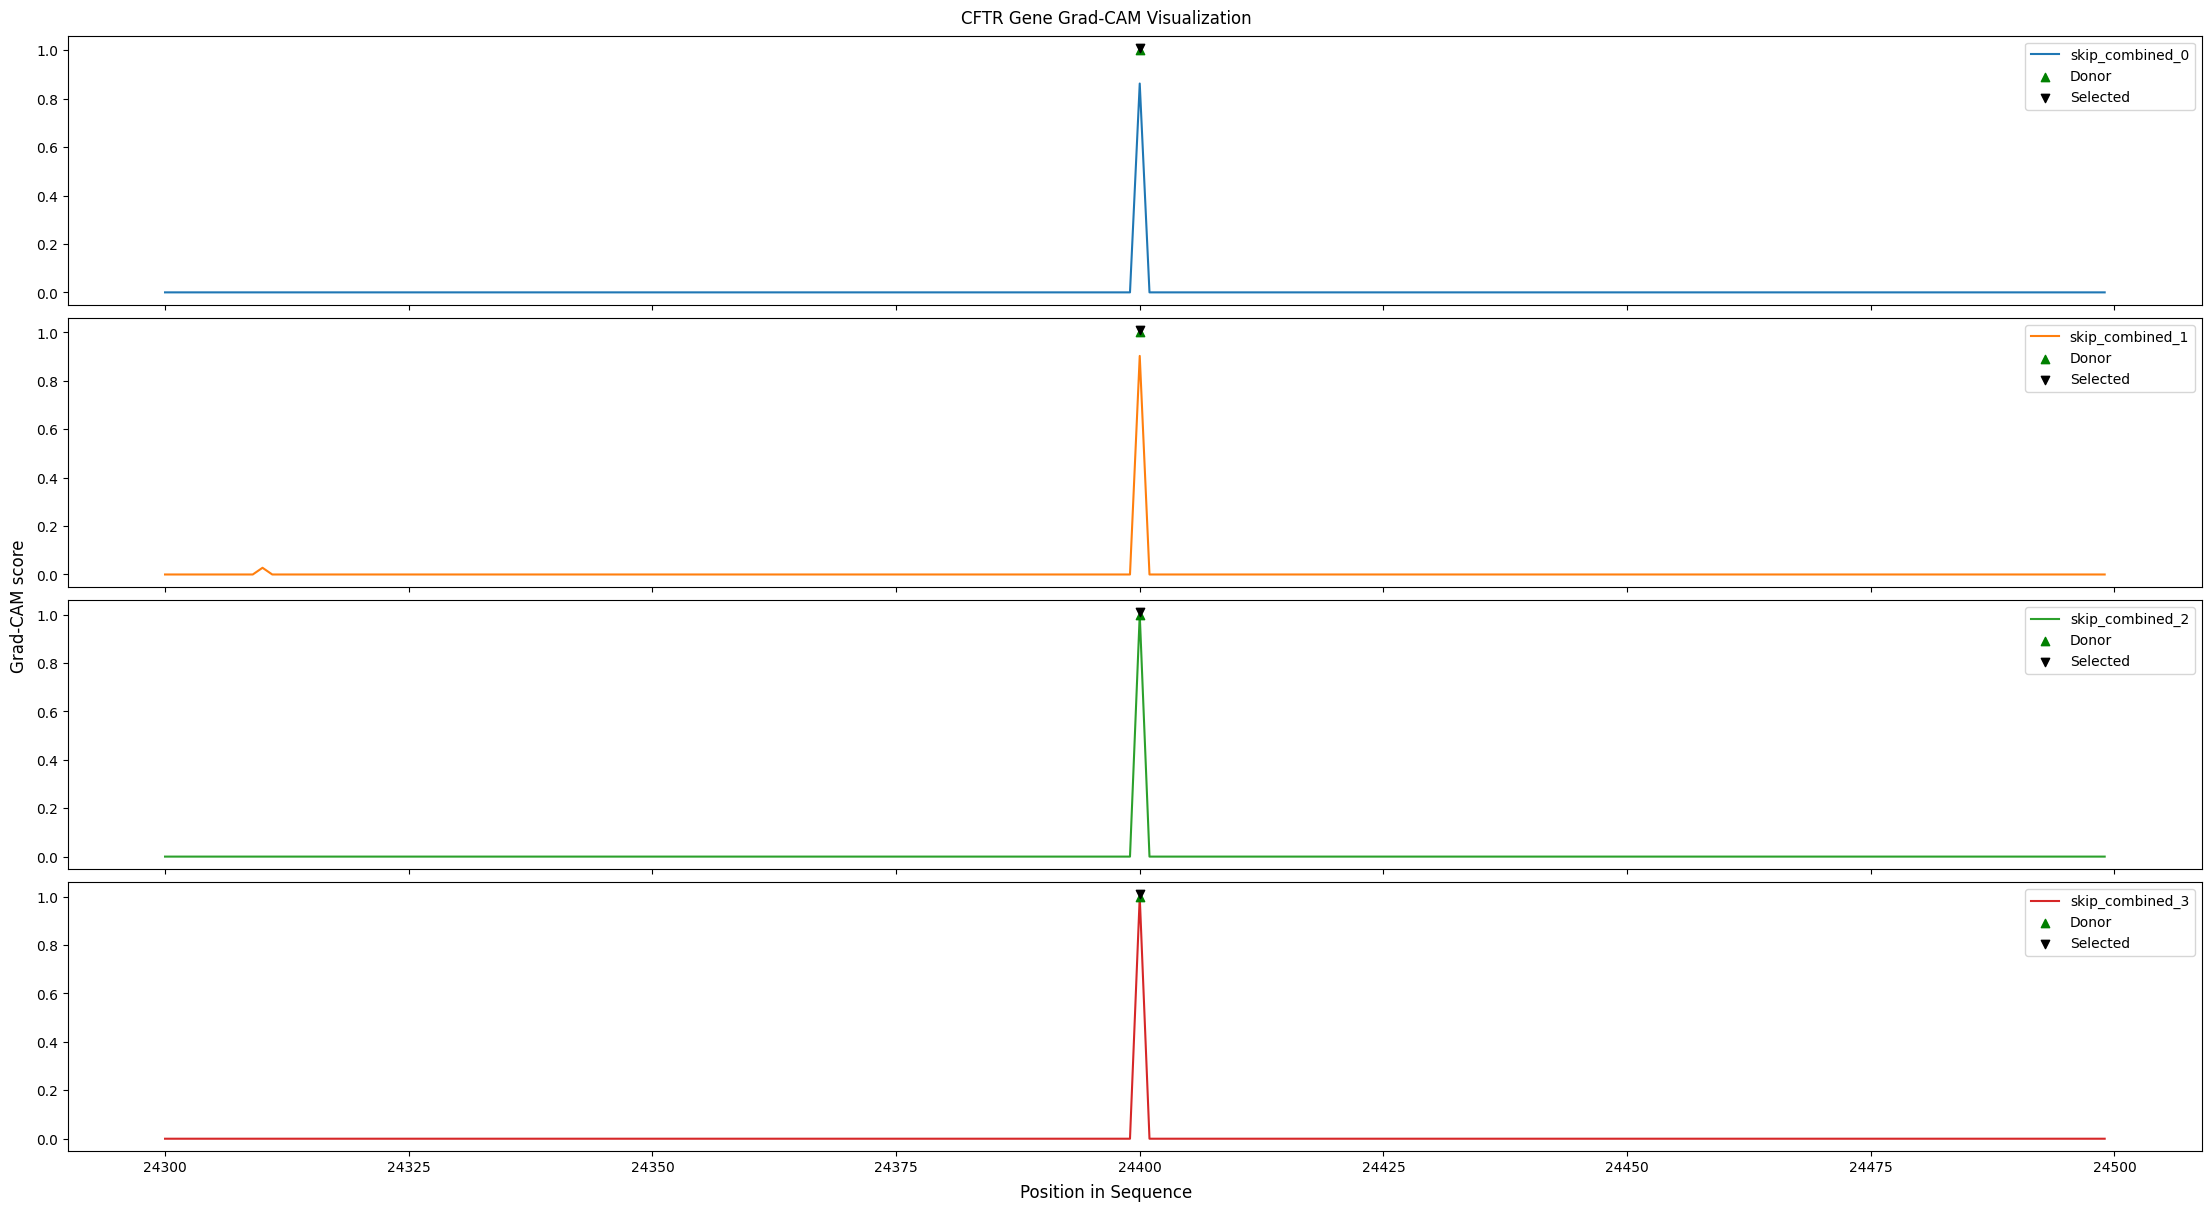

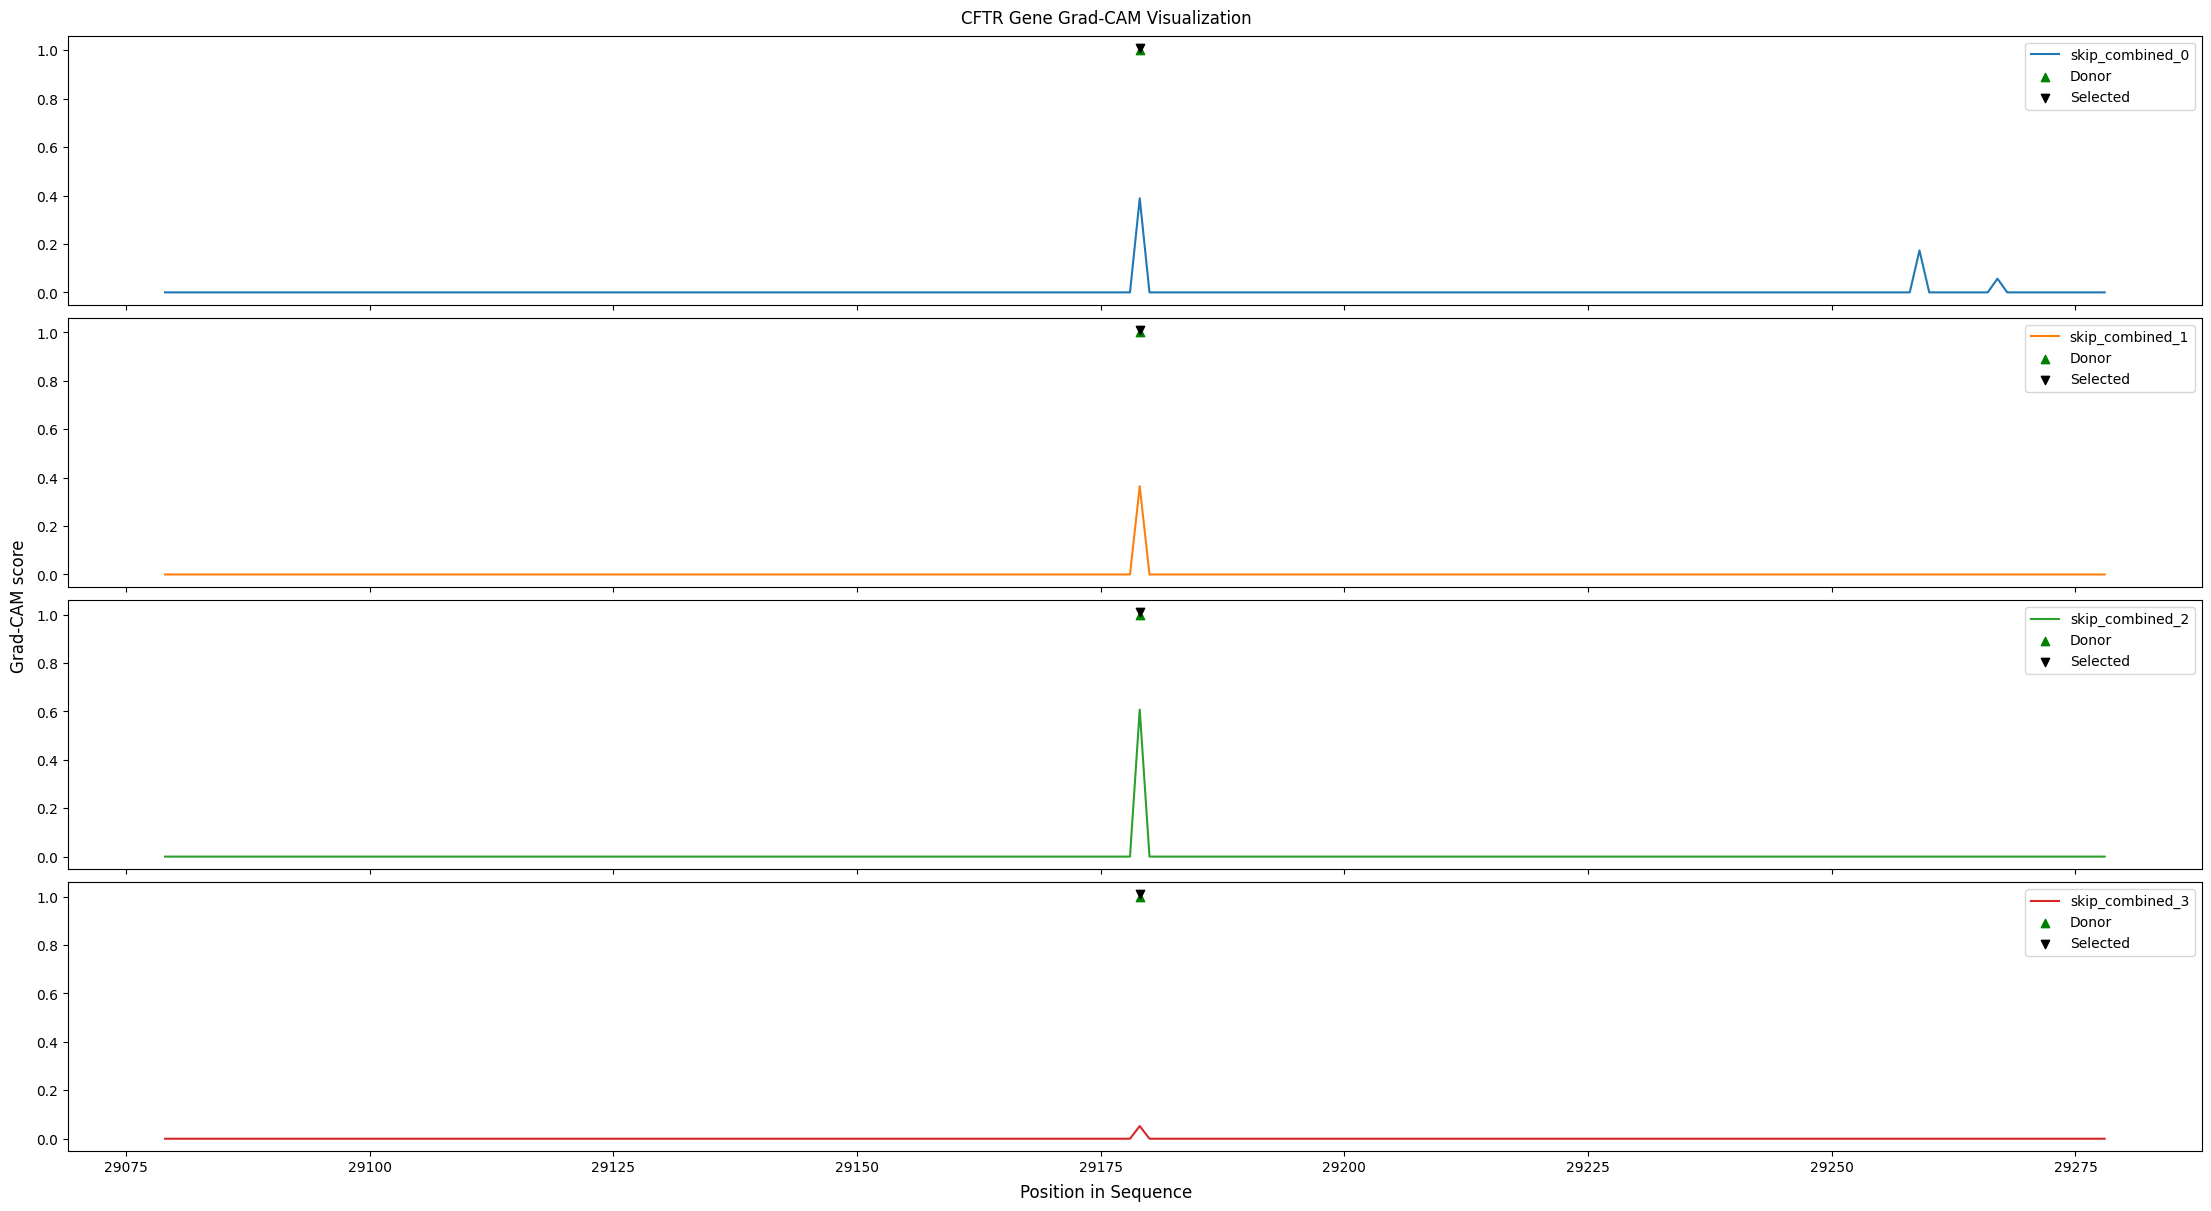

In [24]:
plotter(targets,'../Results/Grad-CAM/CFTR_SpliceAI10k_skips_4.pkl')

### Testing Transformer-40k on another transcript that is much shorter (hundreds of nt), to see how Grad-CAM results compare

In [10]:
# Just some quick code to grab a new transcript
import gffutils
data_dir = '../Data/'
fasta_file_path = '../Data/genome.fa'
gtf_file_path = '../Data/Homo_sapiens.GRCh38.87.gtf'
fname = data_dir+gtf_file_path.split('/')[-1][:-4]+'.db'
db = gffutils.FeatureDB(fname)

genes = db.features_of_type('gene')
CHROM_GROUP = ['chr1', 'chr3', 'chr5', 'chr7', 'chr9']

for gene in tqdm(genes): 
        chrom = 'chr' + gene[0]
        
        if chrom not in CHROM_GROUP:
            continue
        current_chrom = chrom

        strand = gene[6]
        gene_start = gene[3]
        gene_end = gene[4]
        transcripts = db.children(gene, featuretype="transcript")
        for transcript in transcripts:
            transcript_id = transcript['transcript_id'][0]
            if transcript['transcript_biotype'][0]!='protein_coding':
                continue
            if transcript['transcript_support_level'][0] not in ['1']:
                continue

            tx_start = int(transcript[3])
            tx_end = int(transcript[4])

            if tx_end - tx_start < 800:
                print(transcript)


3174it [00:01, 4292.28it/s]

1	havana	transcript	100266289	100266929	.	+	.	gene_id "ENSG00000137996"; gene_version "12"; transcript_id "ENST00000370126"; transcript_version "1"; gene_name "RTCA"; gene_source "ensembl_havana"; gene_biotype "protein_coding"; havana_gene "OTTHUMG00000010920"; havana_gene_version "2"; transcript_name "RTCA-003"; transcript_source "havana"; transcript_biotype "protein_coding"; havana_transcript "OTTHUMT00000030100"; havana_transcript_version "1"; tag "basic"; transcript_support_level "1";
1	ensembl_havana	transcript	155139891	155140544	.	-	.	gene_id "ENSG00000179085"; gene_version "7"; transcript_id "ENST00000368400"; transcript_version "4"; gene_name "DPM3"; gene_source "ensembl_havana"; gene_biotype "protein_coding"; havana_gene "OTTHUMG00000035335"; havana_gene_version "1"; transcript_name "DPM3-001"; transcript_source "ensembl_havana"; transcript_biotype "protein_coding"; tag "CCDS,basic"; ccds_id "CCDS1095"; havana_transcript "OTTHUMT00000085518"; havana_transcript_version "1"; tr

22152it [00:03, 8481.41it/s] 

7	havana	transcript	76303577	76304295	.	+	.	gene_id "ENSG00000106211"; gene_version "8"; transcript_id "ENST00000429938"; transcript_version "1"; gene_name "HSPB1"; gene_source "ensembl_havana"; gene_biotype "protein_coding"; havana_gene "OTTHUMG00000023228"; havana_gene_version "3"; transcript_name "HSPB1-003"; transcript_source "havana"; transcript_biotype "protein_coding"; havana_transcript "OTTHUMT00000341396"; havana_transcript_version "1"; tag "basic"; transcript_support_level "1";


28563it [00:04, 11993.21it/s]

9	ensembl_havana	transcript	34661896	34662692	.	-	.	gene_id "ENSG00000213927"; gene_version "3"; transcript_id "ENST00000259631"; transcript_version "4"; gene_name "CCL27"; gene_source "ensembl_havana"; gene_biotype "protein_coding"; havana_gene "OTTHUMG00000019834"; havana_gene_version "2"; transcript_name "CCL27-001"; transcript_source "ensembl_havana"; transcript_biotype "protein_coding"; tag "CCDS,basic"; ccds_id "CCDS6569"; havana_transcript "OTTHUMT00000052228"; havana_transcript_version "1"; transcript_support_level "1";


58051it [00:05, 9870.83it/s] 


In [81]:
specific_anno = annotation_test[annotation_test['name'].apply(lambda x: x.split('--')[0])=='CCL27']
CL_max = 40000
SL = 5000
device = torch.device('cpu')
test_dataset = spliceDataset(getDataPointListFull(specific_anno,transcriptToLabel_test,SL,CL_max,shift=SL))
test_dataset.seqData = seqData
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
for i,(batch_chunks,target_chunks) in enumerate(tqdm(test_loader)):
    batch_features = batch_chunks.to(torch.float32).to(device)      # shape: [1, 4, 45000]
    targets = torch.squeeze(target_chunks.to(torch.float32).to(device), dim=0)  # shape: [3, 45000]
    
    signal = batch_features[0].sum(dim=0)  # shape: [45000]
    nonzero_positions = torch.nonzero(signal > 0).squeeze()
    print("Transcript spans:", nonzero_positions.min().item(), "to", nonzero_positions.max().item())



100%|██████████| 1/1 [00:00<00:00, 378.62it/s]

Transcript spans: 20000 to 20796


In [26]:
from collections import OrderedDict
activations = {}
gradients = {}

def get_layer_key(i,layer_name):
    return f"model{i}_{layer_name}"

def make_forward_hook(i, layer_name):
    def forward_hook(model, input, output):
        activations[get_layer_key(i, layer_name)] = output
    return forward_hook

def make_backward_hook(i, layer_name):
    def backward_hook(model, grad_input, grad_output):
        gradients[get_layer_key(i, layer_name)] = grad_output
    return backward_hook


NUM_ACCUMULATION_STEPS = 1
temp = 1
n_models = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_m = SpliceFormer(CL_max,bn_momentum=0.01/NUM_ACCUMULATION_STEPS,depth=4,heads=4,n_transformer_blocks=2,determenistic=True,crop=False)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)

#for output_class in [1,2]:
models = [copy.deepcopy(model_m) for i in range(n_models)]

if torch.cuda.device_count() > 1:
    [model.load_state_dict(torch.load('../Results/PyTorch_Models/transformer_encoder_45k_171022_{}'.format(i))) for i,model in enumerate(models)]
else:
    for i,model in enumerate(models):
        state_dict = torch.load('../Results/PyTorch_Models/transformer_encoder_45k_171022_{}'.format(i), map_location=device)
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k[7:] # remove `module.`
            new_state_dict[name] = v
        model.load_state_dict(new_state_dict)

for model in models:
    model.eval()


for i in range(n_models):
    # final_layer = models[i].SpliceAI
    # final_res_layer = models[i].SpliceAI.res_layers[3].comboBlock[3]
    # final_layer.register_forward_hook(make_forward_hook(i, 'Final_Layer'))
    # final_layer.register_full_backward_hook(make_backward_hook(i, 'Final_Layer'))

    # final_res_layer.register_forward_hook(make_forward_hook(i, 'Final_Residual_Block'))
    # final_res_layer.register_full_backward_hook(make_backward_hook(i, 'Final_Residual_Block'))
    for j in range(4):
        models[i].SpliceAI.res_layers[j].register_forward_hook(make_forward_hook(i, f'res_layer_{j}'))
        models[i].SpliceAI.res_layers[j].register_full_backward_hook(make_backward_hook(i, f'res_layer_{j}'))


In [84]:
plot_GradCAM_multilayer(models,batch_features,targets,0,type='Spliceformer')

100%|██████████| 1/1 [00:05<00:00,  5.95s/it]

Donor distance from transcript start:  (array([128, 408]),)
Acceptor distance from transcript start:  (array([276, 613]),)


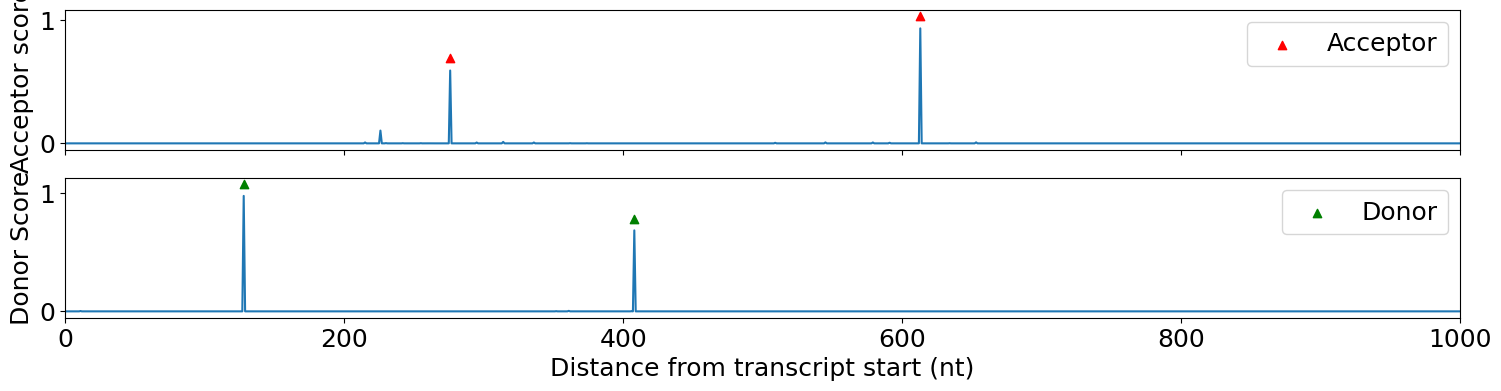

In [70]:
# Testing Transformer-40k performance on transcript

CL_max = 40000
SL = 5000
device = torch.device("cpu")
model_m = SpliceFormer(CL_max, determenistic=True,crop=True)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)
model_m = nn.DataParallel(model_m)

n_models = 10

models = [copy.deepcopy(model_m) for i in range(n_models)]
[model.load_state_dict(torch.load('../Results/PyTorch_Models/transformer_encoder_45k_171022_{}'.format(i), map_location=device)) for i,model in enumerate(models)]
for model in models:
    model.eval()

test_dataset = spliceDataset(getDataPointListFull(specific_anno,transcriptToLabel_test,SL,CL_max,shift=SL))
test_dataset.seqData = seqData
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

Y_true_acceptor, Y_pred_acceptor = [],[]
Y_true_donor, Y_pred_donor = [],[]
l = 1
for i,(batch_chunks,target_chunks) in enumerate(tqdm(test_loader)):
    batch_features = batch_chunks.type(torch.FloatTensor).to(device)
    targets = target_chunks.to(device)[:,:,CL_max//2:-CL_max//2]
    outputs = ([models[i](batch_features)[0].detach() for i in range(n_models)])
    #outputs = (outputs[0]+outputs[1]+outputs[2]+outputs[3]+outputs[4])/n_models
    outputs = torch.stack(outputs)
    outputs = torch.mean(outputs,dim=0)
    #outputs = odds_gmean(outputs)
    #targets_list.extend(targets.unsqueeze(0))
    #outputs_list.extend(outputs.unsqueeze(0))

    targets = torch.transpose(targets,1,2).cpu().numpy()
    outputs = torch.transpose(outputs,1,2).cpu().numpy()
    is_expr = (targets.sum(axis=(1,2)) >= 1)
    Y_true_acceptor.extend(targets[is_expr, :, 1].flatten())
    Y_true_donor.extend(targets[is_expr, :, 2].flatten())
    Y_pred_acceptor.extend(outputs[is_expr, :, 1].flatten())
    Y_pred_donor.extend(outputs[is_expr, :, 2].flatten())
    # l += 1
    # if l>1:
    #     break
Y_true_acceptor, Y_pred_acceptor = np.array(Y_true_acceptor), np.array(Y_pred_acceptor)
Y_true_donor, Y_pred_donor = np.array(Y_true_donor), np.array(Y_pred_donor)


fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(18, 4),sharex=True)
ax1.plot(Y_pred_acceptor)
ax2.plot(Y_pred_donor)
cond = (Y_true_acceptor==1)
ax1.scatter(np.where(Y_true_acceptor==1),Y_pred_acceptor[cond]+0.1,c='red',marker="^", clip_on=False, zorder=10,label='Acceptor')
cond = (Y_true_donor==1)
ax2.scatter(np.where(Y_true_donor==1),Y_pred_donor[cond]+0.1,c='green',marker="^", clip_on=False, zorder=10,label='Donor')
plt.xlabel('Distance from transcript start (nt)')
ax1.set_ylabel('Acceptor score')
ax1.set_xlim([0,1000])
ax2.set_ylabel('Donor Score')
ax1.legend()
ax2.legend()
print('Donor distance from transcript start: ', np.where(Y_true_donor==1))
print('Acceptor distance from transcript start: ', np.where(Y_true_acceptor==1))

# plt.savefig('../Results/Transformer_CFTR_scores.png', dpi=400)
plt.show()

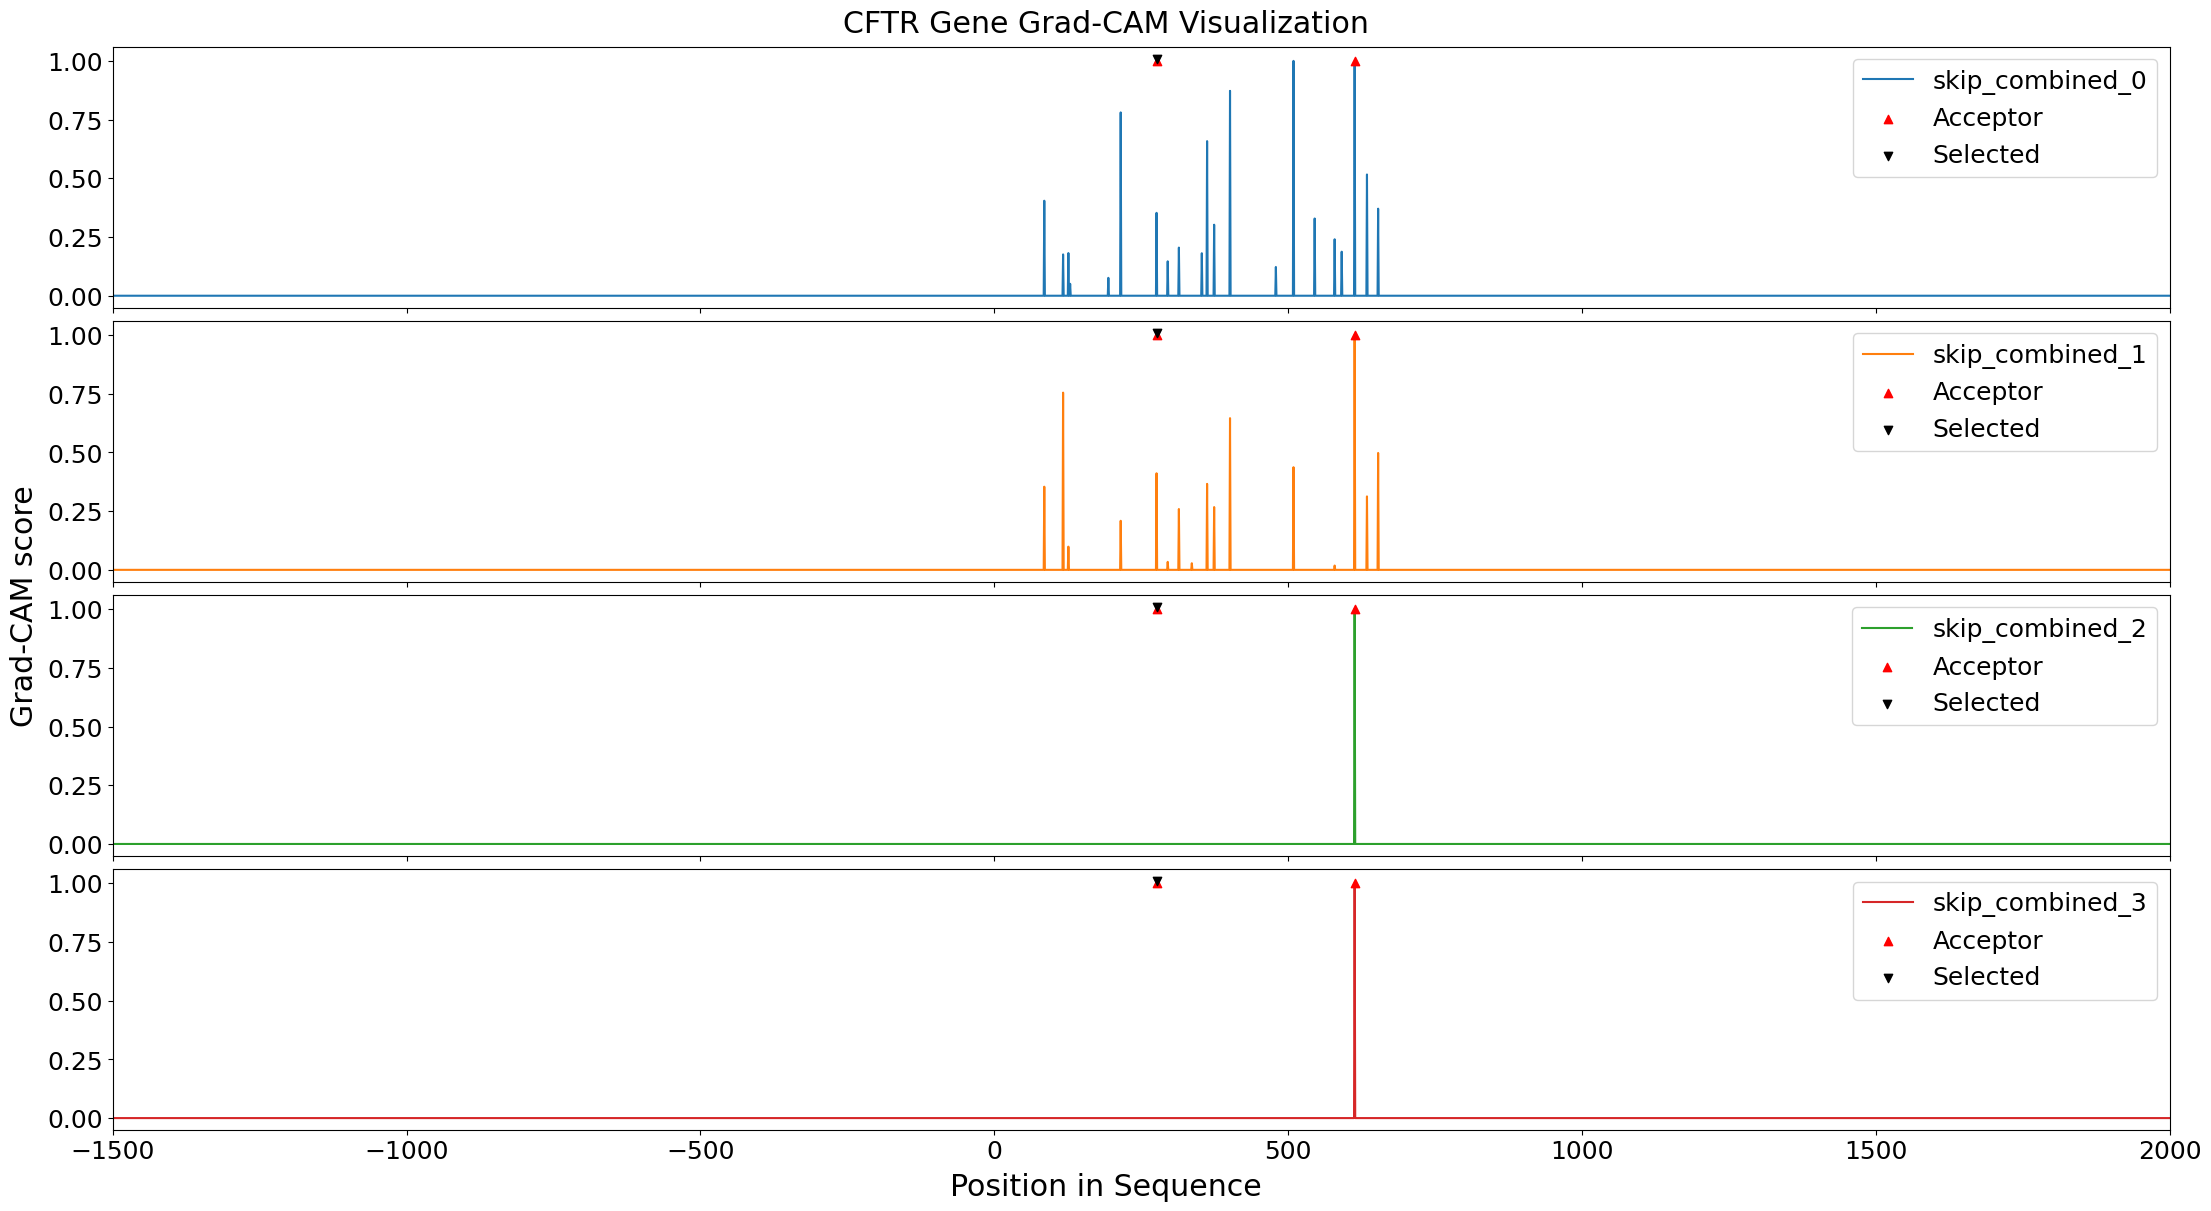

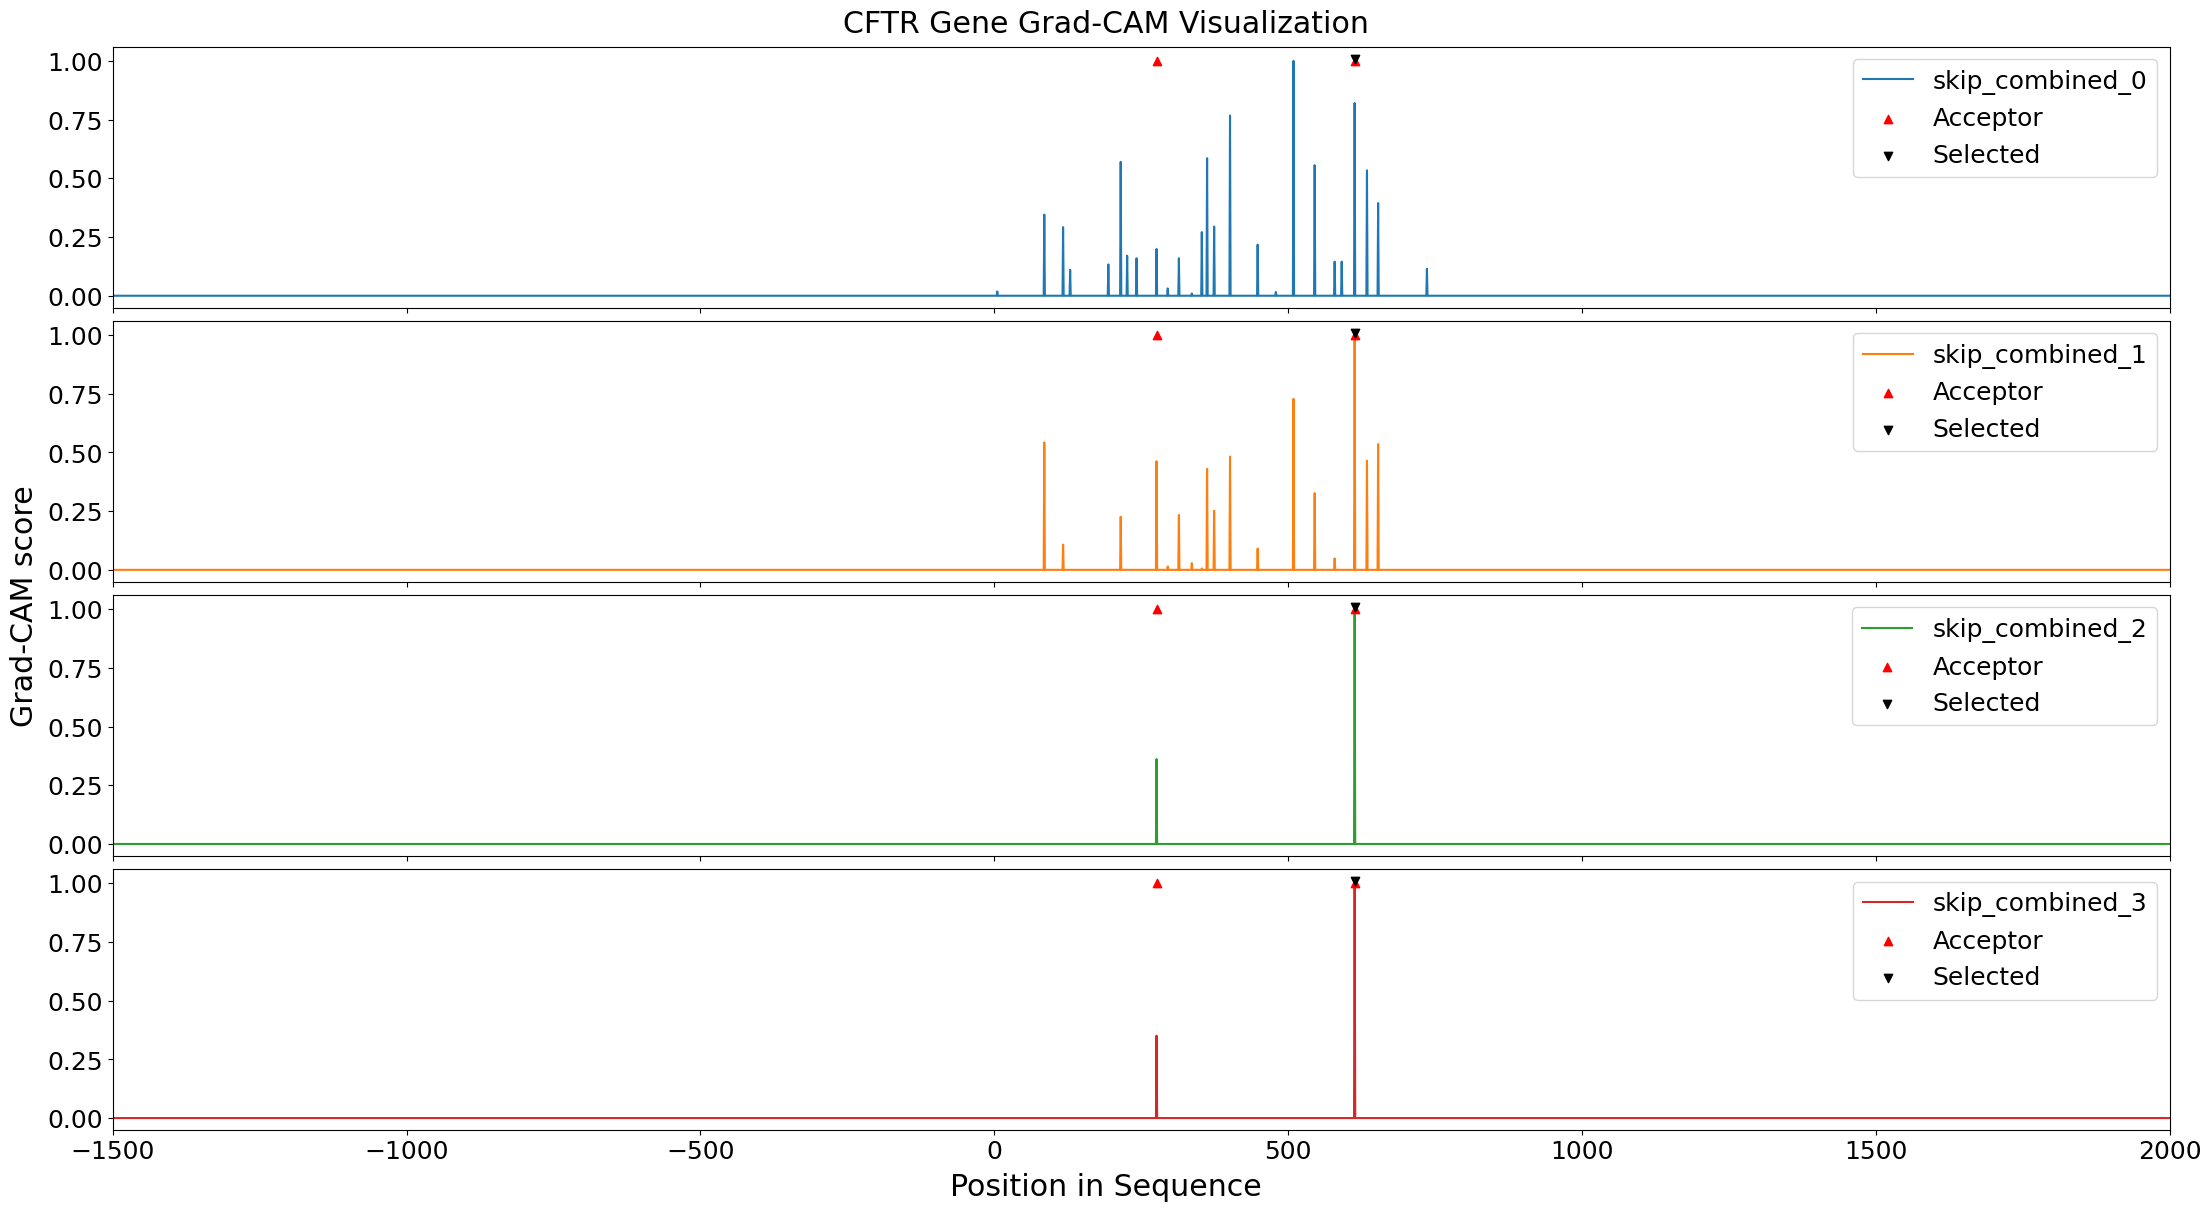

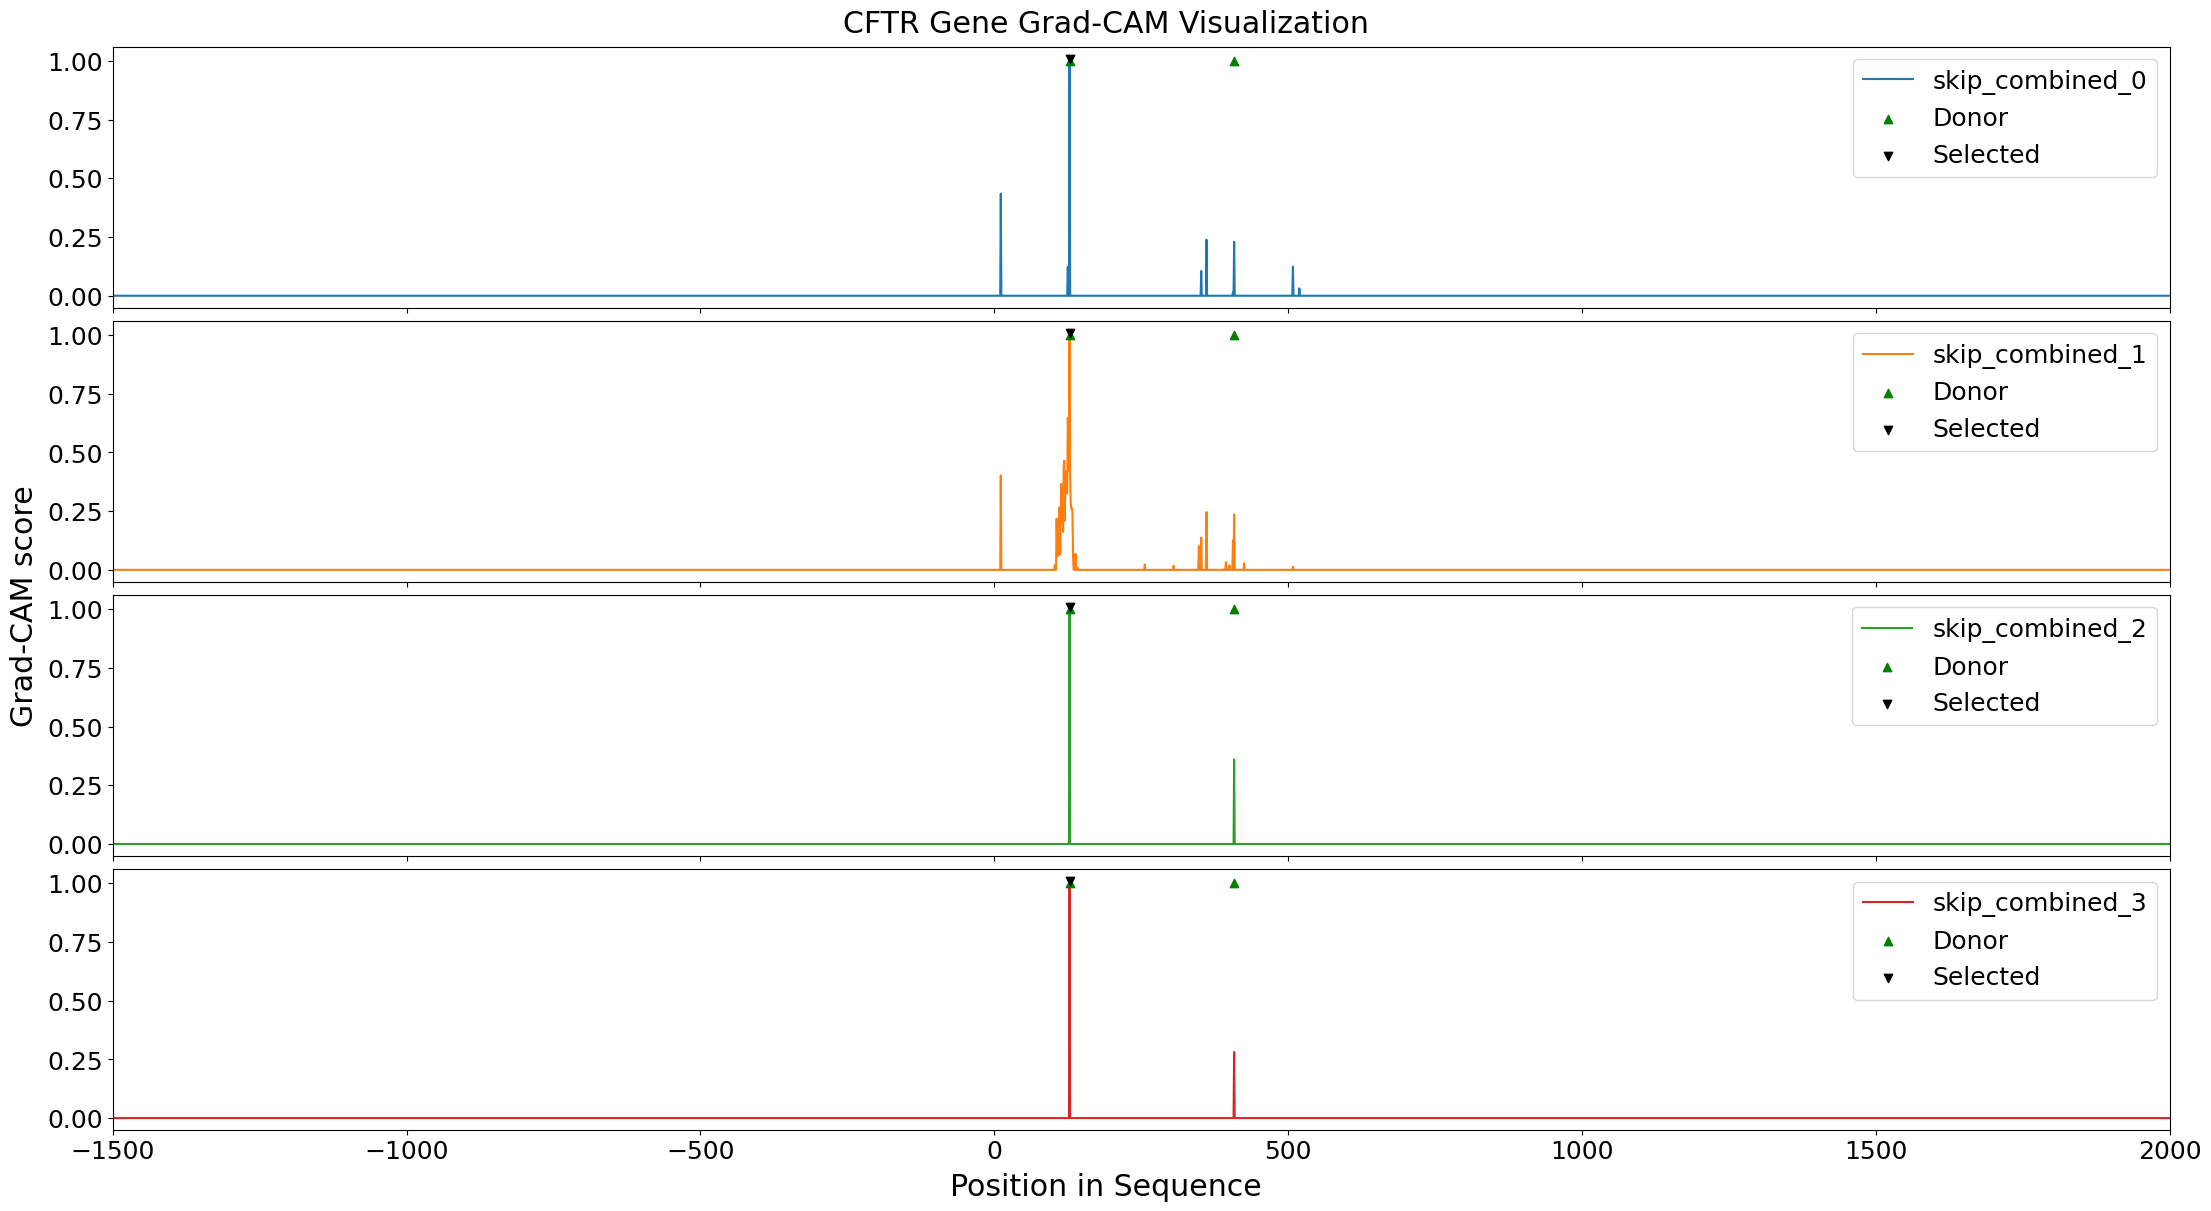

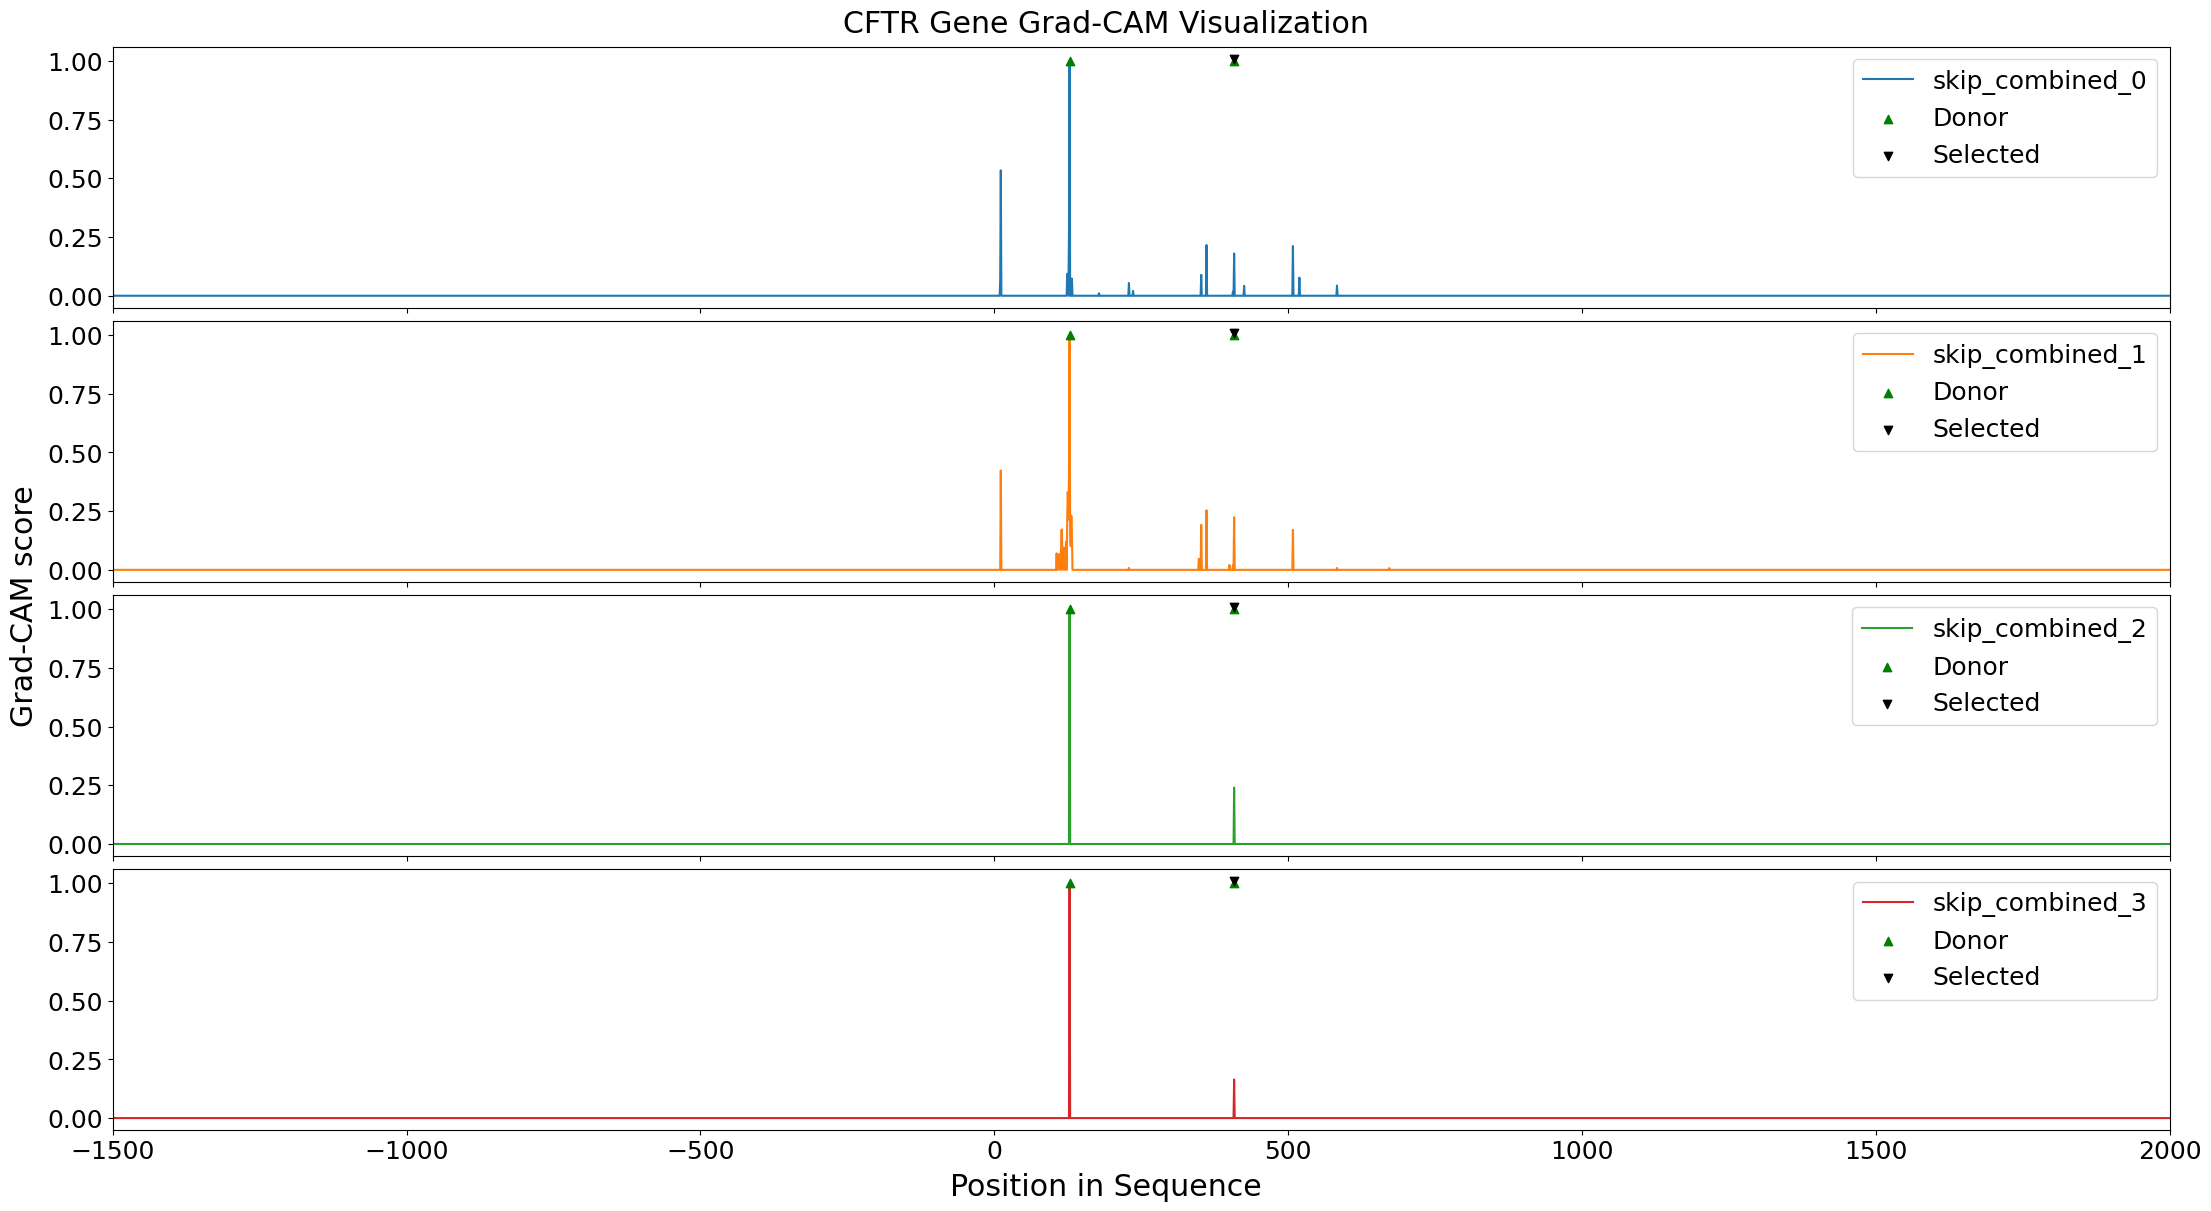

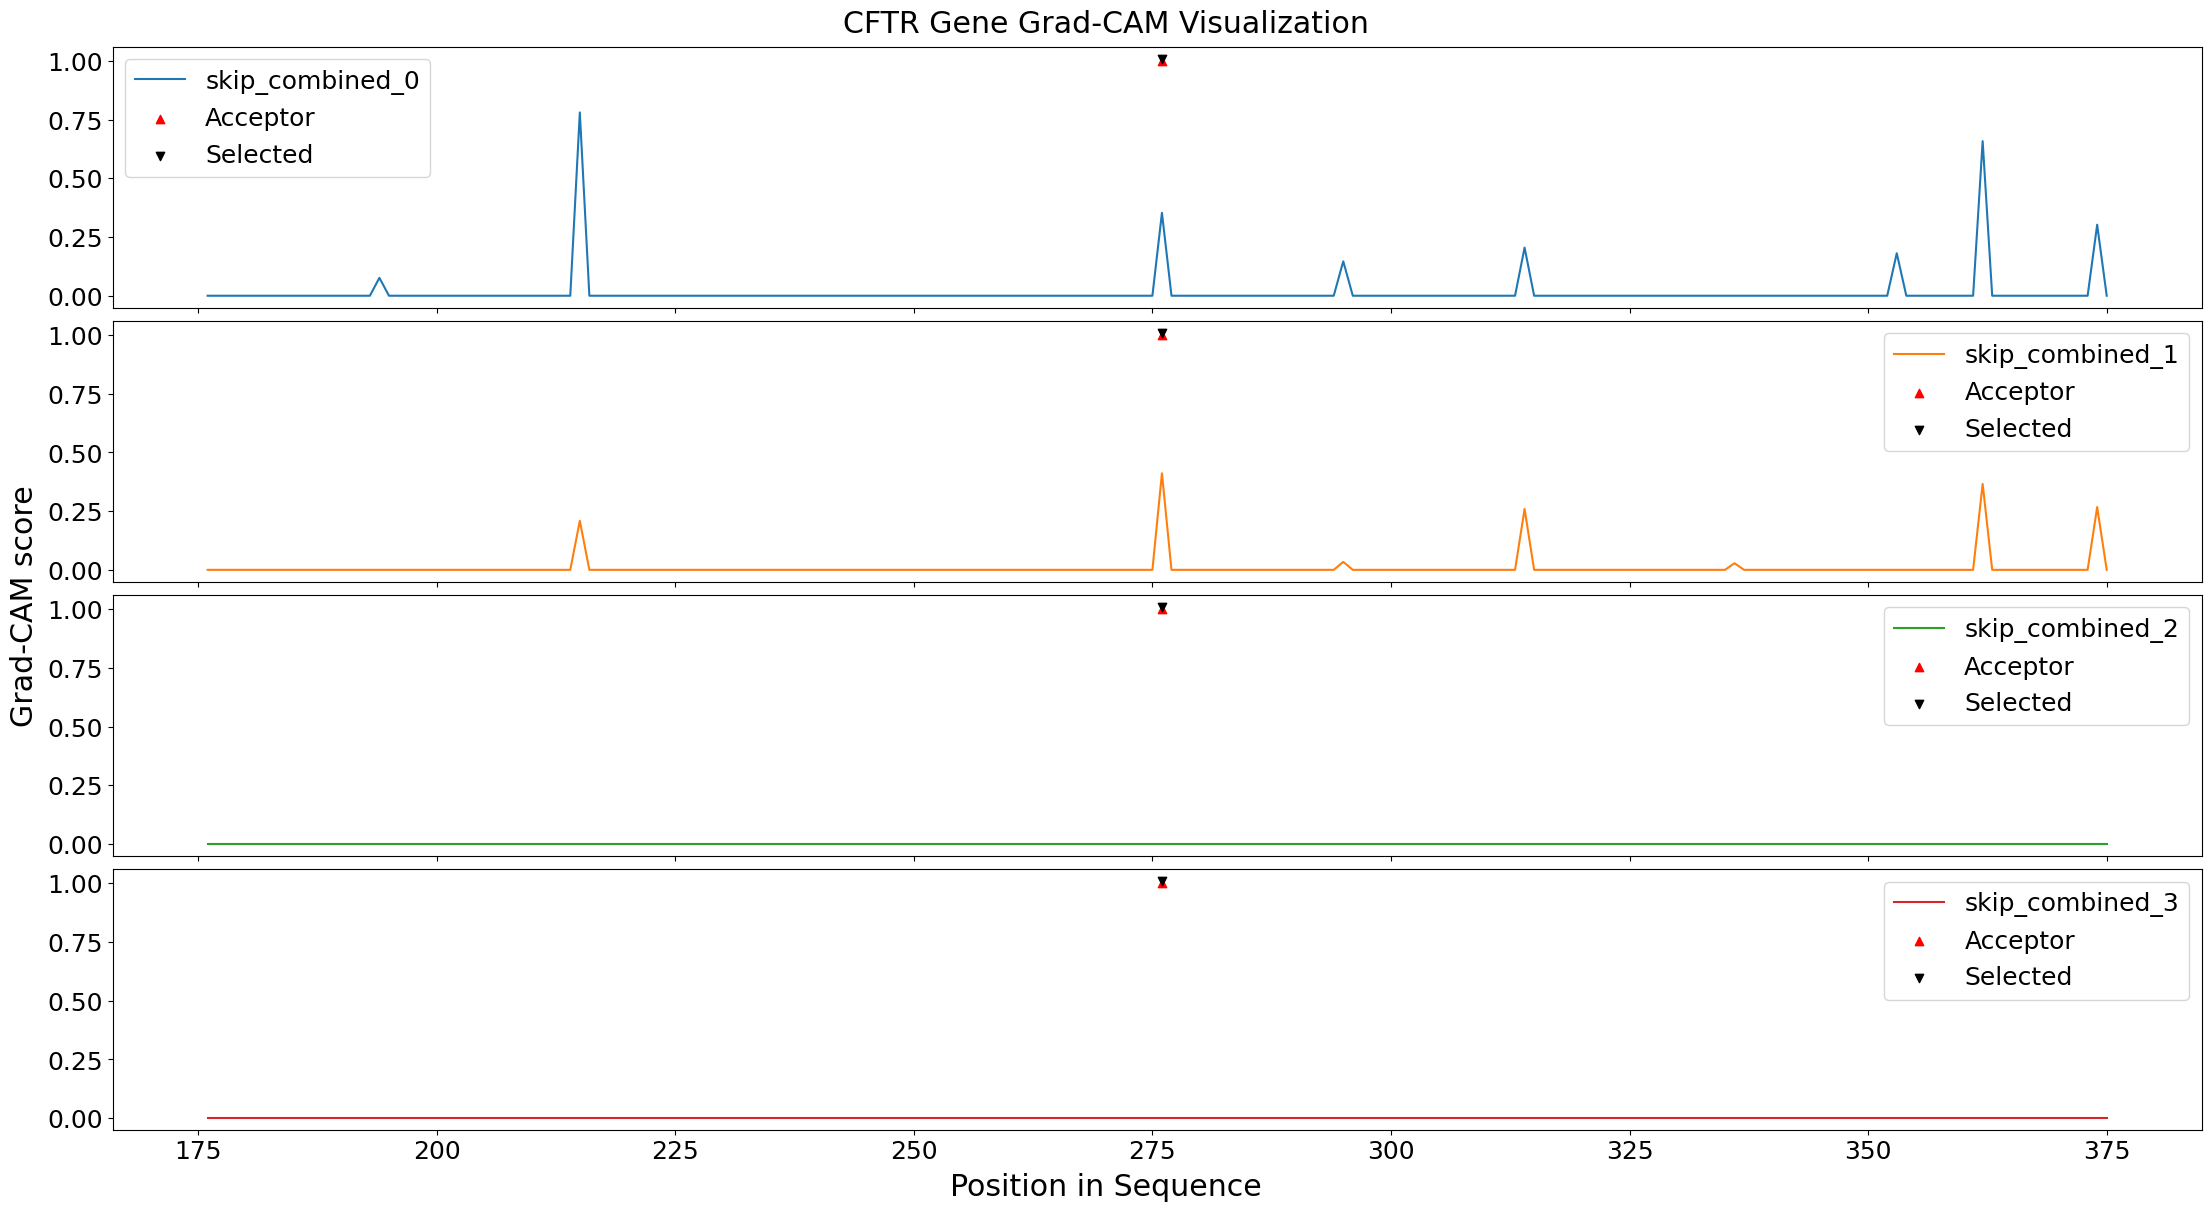

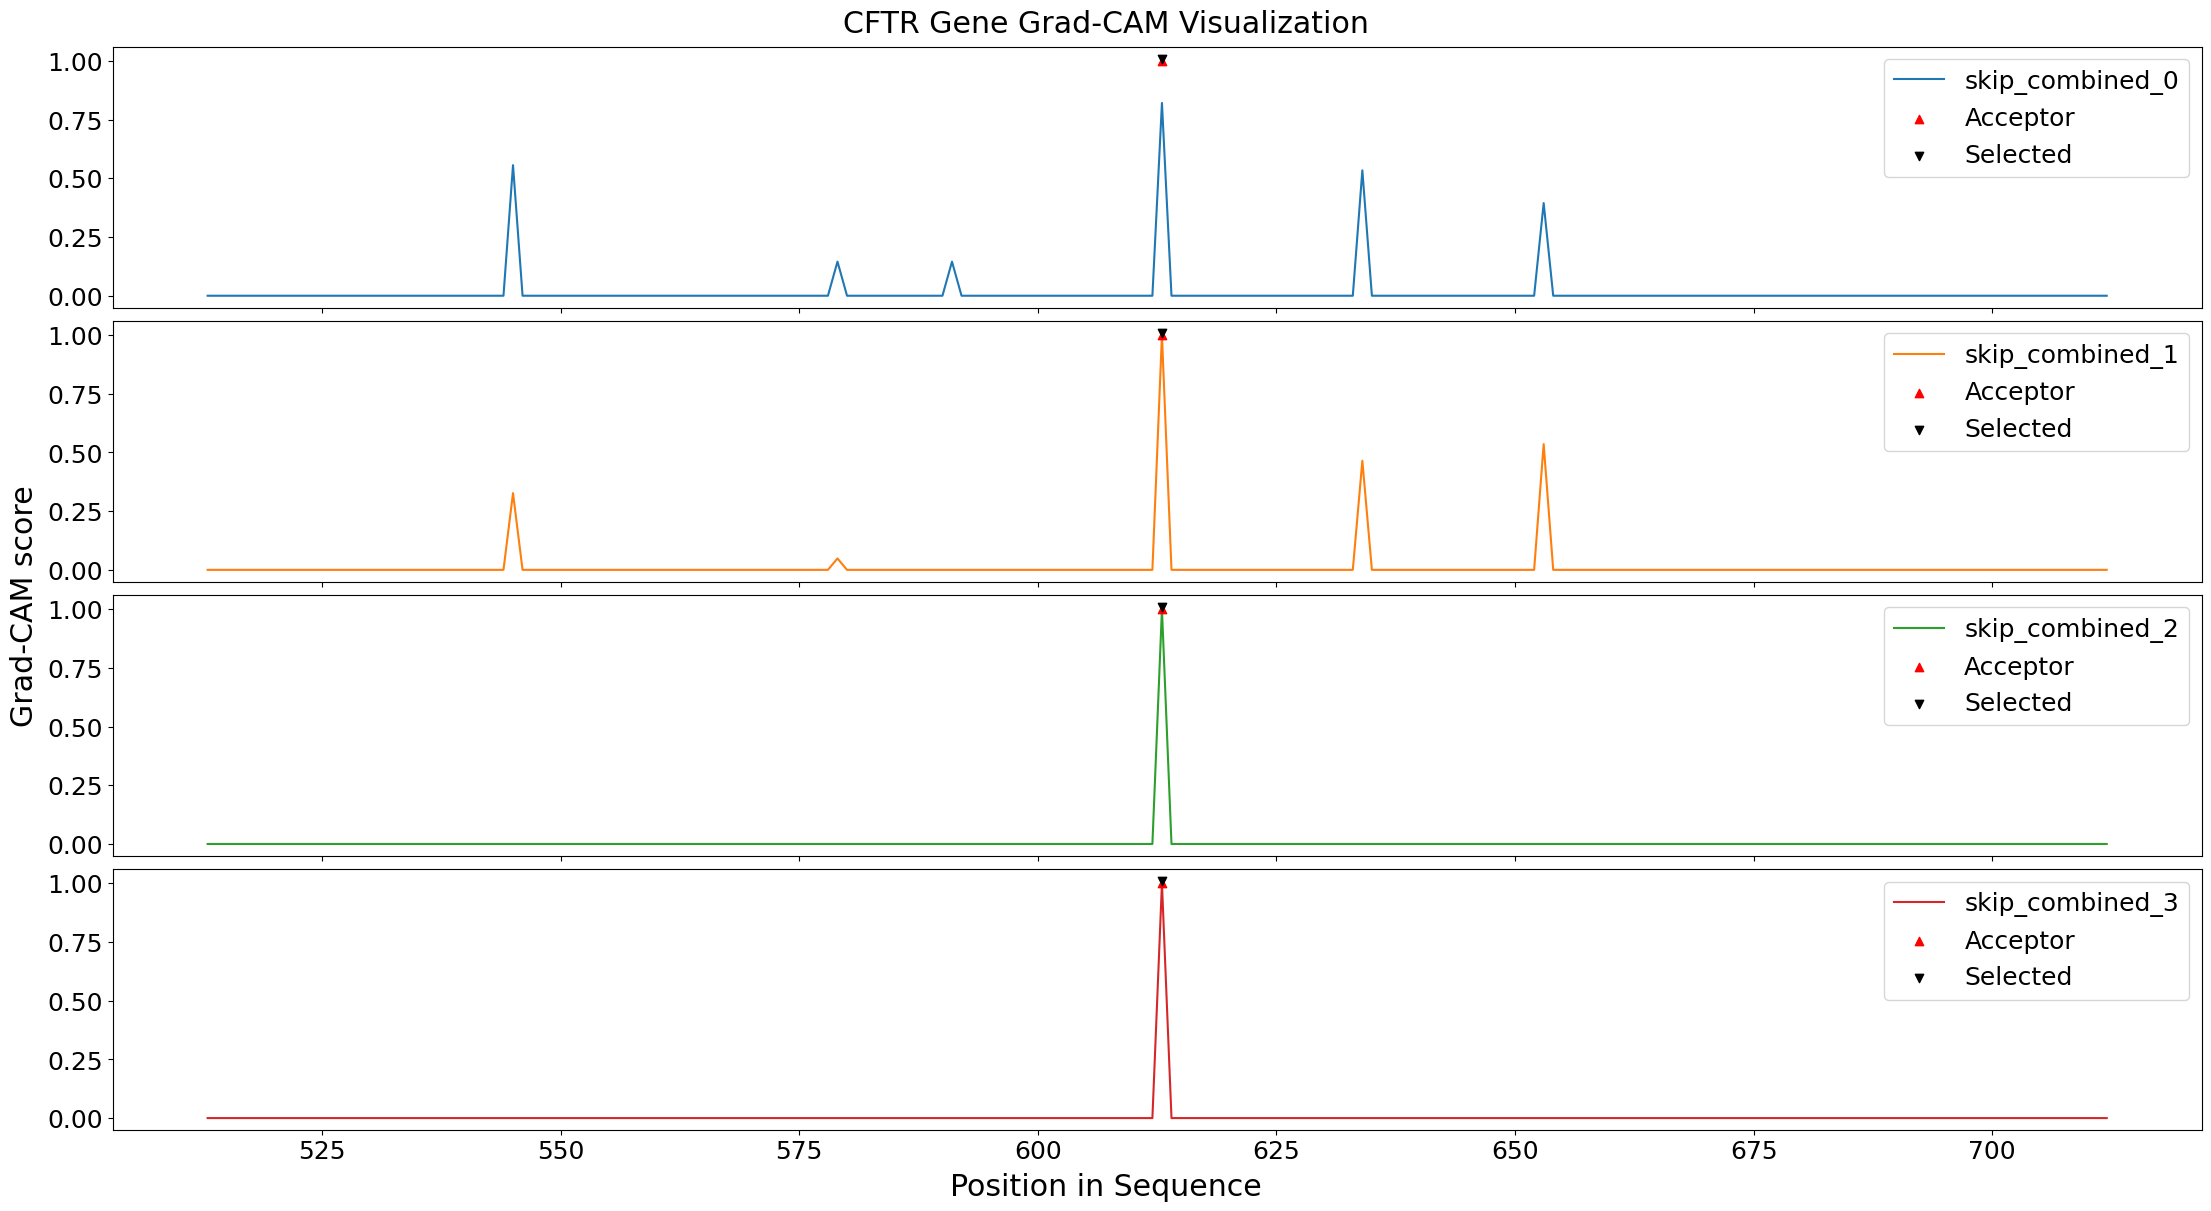

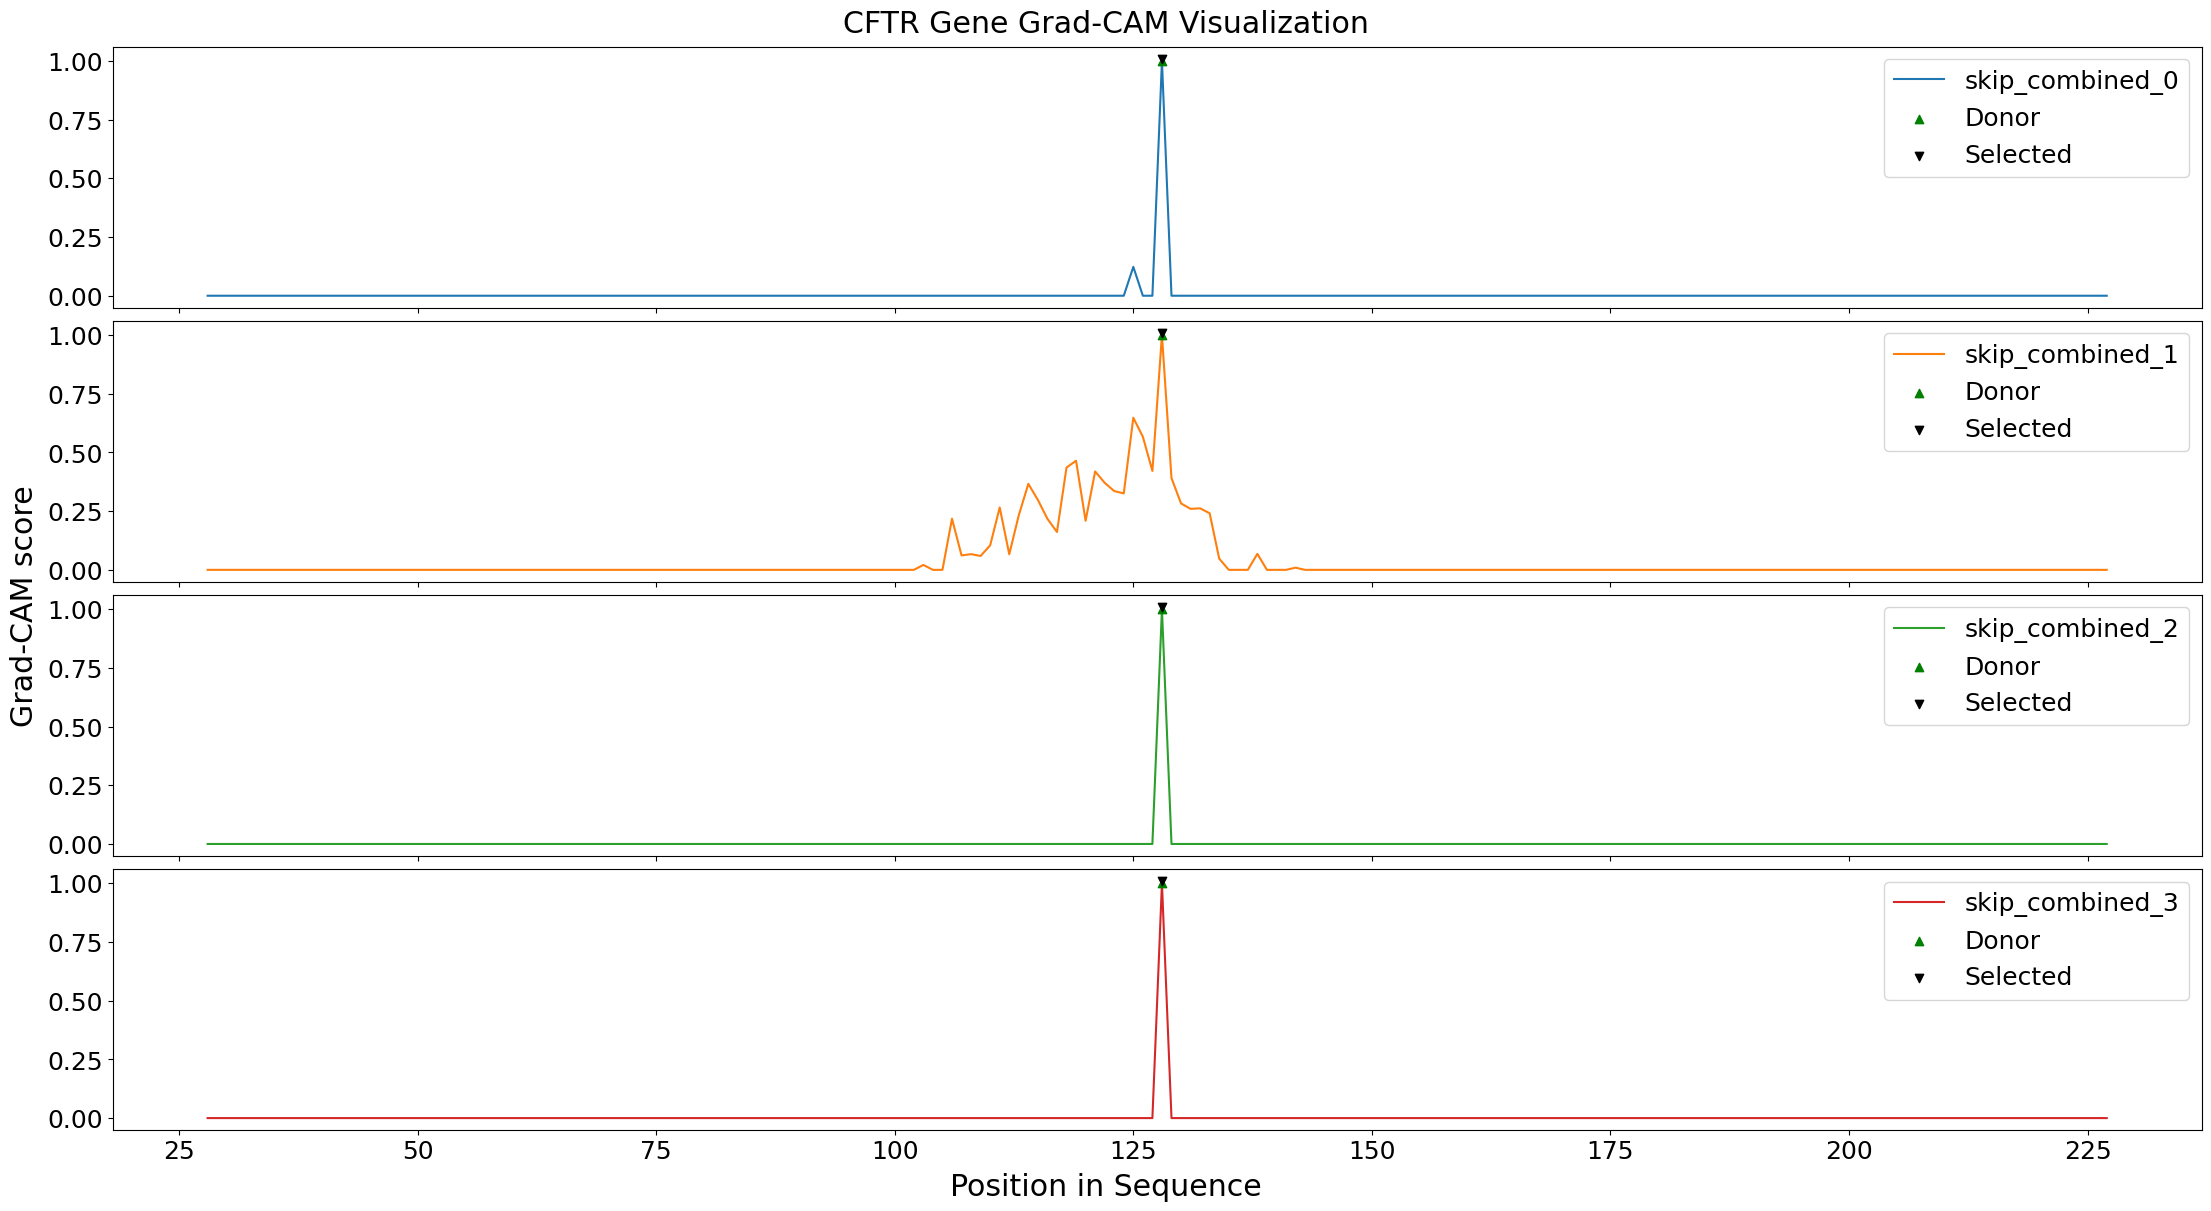

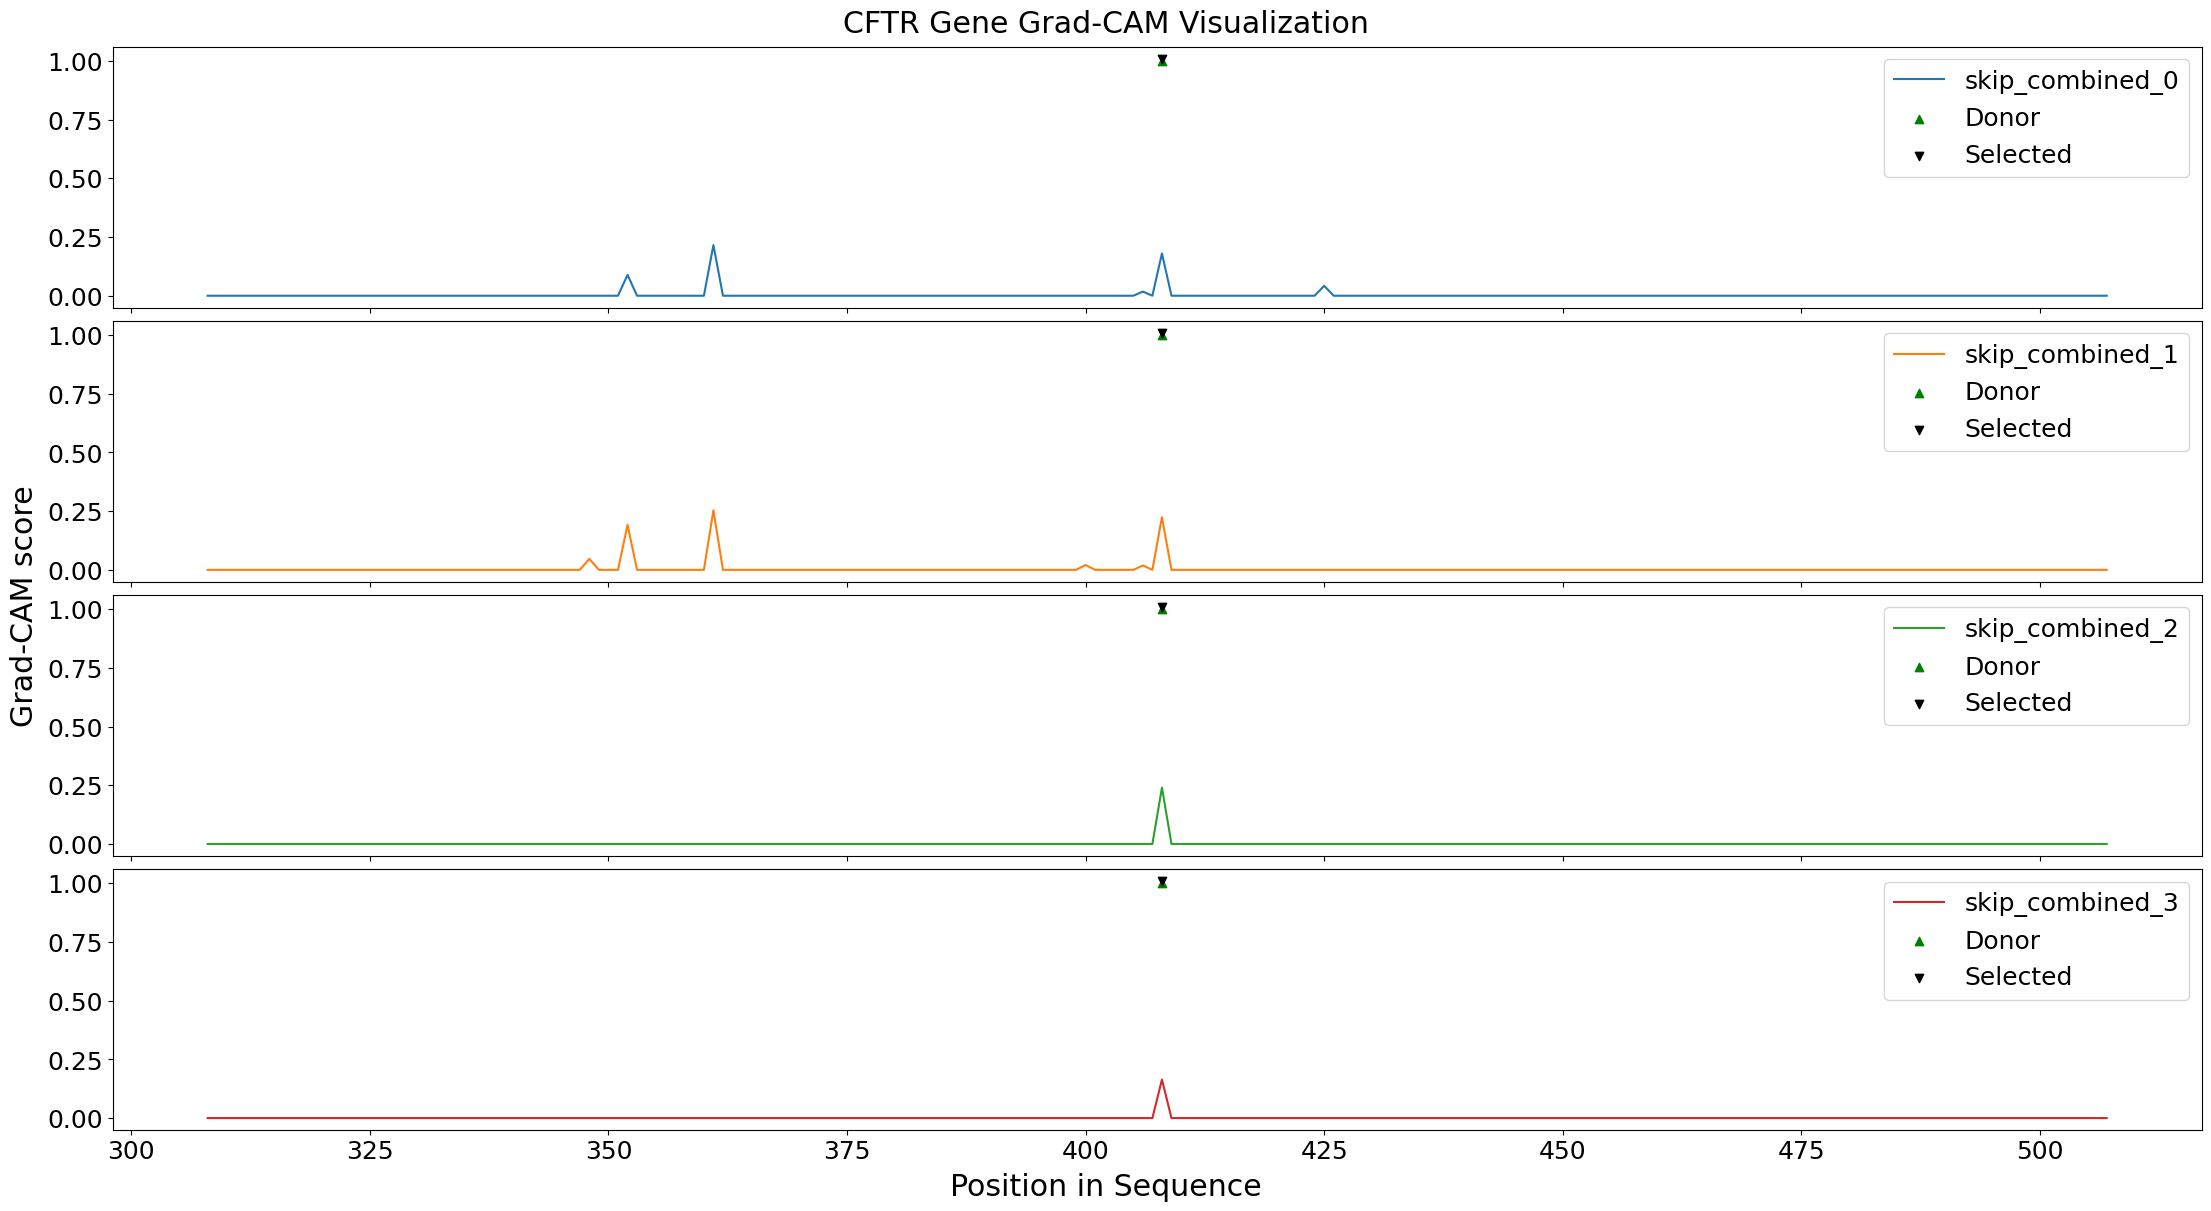

In [86]:
plotter(targets,'../Results/Grad-CAM/CCL27_Transformer45k_skips.pkl')